# MRI 脑体素分割 - 使用Kolmogorov-Arnold网络(KAN)

这个笔记本演示如何使用KAN (Kolmogorov-Arnold Networks)替代传统MLP进行MRI脑体素分割。KAN是一种新型神经网络结构，它使用可学习的激活函数来提高性能和可解释性。

我们将使用与原始MLP相同的MRI数据，但应用KAN架构，并比较其性能。

In [4]:
# 导入KAN和其他必要的库
from fastkan import *
# from efficient_kan import *
import matplotlib.pyplot as plt
import h5py
import scipy.io
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import time
import os
import torch
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
# 设置matplotlib显示中文
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False    # 用来正常显示负号

print("所有库导入成功！")

所有库导入成功！


In [6]:
# 设置计算设备
if torch.cuda.is_available():
    device = torch.device('cuda')
    # 获取GPU信息
    gpu_name = torch.cuda.get_device_name(0)
    gpu_count = torch.cuda.device_count()
    print(f"使用设备: {device} ({gpu_name})")
    print(f"可用GPU数量: {gpu_count}")
    !nvidia-smi
else:
    device = torch.device('cpu')
    print(f"使用设备: {device}")


使用设备: cuda (NVIDIA L4)
可用GPU数量: 2
Fri Feb 28 18:09:00 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.90.07              Driver Version: 550.90.07      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      On  |   00000000:00:03.0 Off |                    0 |
| N/A   46C    P8             17W /   72W |       4MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-------------

In [2]:
# 修改cell3-parameters部分，确保network_structure变量正确定义

# 设置参数和路径
output_path = '/home/jannik/Documents/brain_voxel_data/output/'  # 修改为您的数据保存路径
export_path = '/home/jannik/Documents/brain_voxel_data/output/kan_models/'  # KAN模型保存路径
# output_path = './brain_voxel_data/output'
# export_path = './brain_voxel_data/output/kan_models/'

# 确保模型保存路径存在
os.makedirs(export_path, exist_ok=True)

# 设置训练参数
no_classes = 102  # 分类数量
batch_size = 256  # Adam优化器的批量大小
learning_rate = 0.001  # Adam优化器的学习率

# 设置KAN网络结构 - 确保这个变量被正确定义
network_structure = [341, 512, 256, 102]  # [输入维度, 隐藏层1, 隐藏层2, 输出维度]
# network_structure = [341, 256, 102]  # [输入维度, 隐藏层1, 隐藏层2, 输1出维度]
print(f"KAN网络结构: {network_structure}")

# 网格策略设计 - 指数型增长
# 设置网格扩展次数和初始网格大小
# n_grid_extensions = 80  # 总共进行80次网格扩展
# initial_grid = 3  # 从网格大小2开始
# max_grid = 1000  # 最大网格大小1000
n_grid_extensions = 80  # 总共进行80次网格扩展
initial_grid = 3  # 从网格大小2开始
max_grid = 1000  # 最大网格大小1000

# 生成指数增长的网格序列
grid_sequence = [int(initial_grid * (max_grid/initial_grid)**(i/(n_grid_extensions-1))) 
                for i in range(n_grid_extensions)]
# 去重并排序
grid_sequence = sorted(list(set(grid_sequence)))  
# 确保最后一个网格大小不超过最大值
if grid_sequence[-1] > max_grid:
    grid_sequence[-1] = max_grid

# 将网格序列分为三个主要阶段
phase1_end = len(grid_sequence) // 3  # 第1阶段结束索引
phase2_end = 2 * len(grid_sequence) // 3  # 第2阶段结束索引

# 三个主要阶段的网格序列
phase_grid_sequences = [
    grid_sequence[:phase1_end+1],  # 第1阶段网格序列
    grid_sequence[phase1_end+1:phase2_end+1],  # 第2阶段网格序列
    grid_sequence[phase2_end+1:]  # 第3阶段网格序列
]

# 设置每个阶段的训练步数
# 第一阶段使用更多的步数，让模型可以充分学习基本模式
# 后续阶段逐渐减少步数
steps_per_phase = {
    0: 30,  # 第1阶段的每个网格点训练30步
    1: 20,  # 第2阶段的每个网格点训练20步
    2: 10   # 第3阶段的每个网格点训练10步
}

# 计算总训练步数
total_steps = sum(steps_per_phase[i] * len(phase_grid_sequences[i]) for i in range(3))

print(f"参数设置完成，类别数: {no_classes}, 批量大小: {batch_size}")
print(f"学习率: {learning_rate}, 总训练步数: {total_steps}")
print(f"网格扩展次数: {len(grid_sequence)}")
print(f"网格扩展序列: {grid_sequence}")
print(f"\n指数网格训练策略:")
print(f"  阶段1 (网格 {grid_sequence[0]}-{grid_sequence[phase1_end]}): 每个网格点训练 {steps_per_phase[0]} 步")
print(f"  阶段2 (网格 {grid_sequence[phase1_end+1]}-{grid_sequence[phase2_end]}): 每个网格点训练 {steps_per_phase[1]} 步")
print(f"  阶段3 (网格 {grid_sequence[phase2_end+1]}-{grid_sequence[-1]}): 每个网格点训练 {steps_per_phase[2]} 步")

KAN网络结构: [341, 512, 256, 102]
参数设置完成，类别数: 102, 批量大小: 256
学习率: 0.001, 总训练步数: 1410
网格扩展次数: 70
网格扩展序列: [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 20, 21, 23, 25, 27, 29, 31, 33, 36, 39, 42, 45, 49, 52, 56, 61, 65, 70, 76, 82, 88, 95, 102, 110, 118, 127, 137, 147, 159, 171, 184, 198, 213, 229, 247, 266, 286, 308, 331, 357, 384, 413, 445, 479, 515, 555, 597, 643, 692, 745, 802, 863, 929, 1000]

指数网格训练策略:
  阶段1 (网格 3-33): 每个网格点训练 30 步
  阶段2 (网格 36-184): 每个网格点训练 20 步
  阶段3 (网格 198-1000): 每个网格点训练 10 步


In [ ]:
# import numpy as np
# import h5py
# from sklearn.preprocessing import StandardScaler

# # 文件路径
# data_path = '/home/jannik/Documents/brain_voxel_data/TRAIN38.mat'
# output_path = '/home/jannik/Documents/brain_voxel_data/output'

# # 读取数据
# f = h5py.File(data_path, 'r')
# arrays = {k: np.array(v) for k, v in f.items()}
# f.close()

# train_data = arrays['data'].transpose()
# train_region = arrays['region'].transpose()
# prob_idx = arrays['prob_idx'].transpose()

# # 数据分割 - 38号作为验证集，其余作为完整训练集
# train_indices = np.where(prob_idx != 38)[0]
# x_train_full = train_data[train_indices, :]
# y_train_full = train_region[train_indices, :]

# val_indices = np.where(prob_idx == 38)[0]
# val_data = train_data[val_indices, :]
# val_label = train_region[val_indices, :]

# # 标准化
# scaler = StandardScaler()
# scaler.fit(x_train_full)
# x_train_full = scaler.transform(x_train_full)
# val_data = scaler.transform(val_data)

# # 保存数据
# np.save(f"{output_path}/x_train_full.npy", x_train_full)
# np.save(f"{output_path}/y_train_full.npy", y_train_full)
# np.save(f"{output_path}/val_data.npy", val_data)
# np.save(f"{output_path}/val_label.npy", val_label)

# print(f"Data saved to {output_path}")

In [1]:
import numpy as np
import os

# 文件路径
input_path = '/home/jannik/Documents/brain_voxel_data/output/full'
output_path = '/home/jannik/Documents/brain_voxel_data/output/by_label'

# 创建输出目录（如果不存在）
os.makedirs(output_path, exist_ok=True)

# 加载数据
x_train_full = np.load(f"{input_path}/x_train_full.npy")
y_train_full = np.load(f"{input_path}/y_train_full.npy")

print(f"加载数据: X shape = {x_train_full.shape}, Y shape = {y_train_full.shape}")

# 确认标签是one-hot编码
num_labels = y_train_full.shape[1]
if num_labels != 102:
    print(f"警告: 标签数量 {num_labels} 与预期的 102 不符")

# 提取每个标签的体素
for label_idx in range(num_labels):
    # 找到标签为label_idx的所有体素索引
    # 在one-hot编码中，标签位置的值为1
    voxel_indices = np.where(y_train_full[:, label_idx] == 1)[0]
    
    if len(voxel_indices) == 0:
        print(f"标签 {label_idx} 没有对应的体素")
        continue
    
    # 提取这些体素的biosignature数据
    label_voxels = x_train_full[voxel_indices]
    
    # 保存到文件，文件名中包含体素数量信息
    voxel_count = len(voxel_indices)
    output_file = f"{output_path}/label_{label_idx}_count_{voxel_count}_voxels.npy"
    np.save(output_file, label_voxels)
    
    print(f"标签 {label_idx}: 提取了 {voxel_count} 个体素，形状 {label_voxels.shape}，保存到 {output_file}")

print("所有标签的体素数据提取完成")

# 验证提取结果
total_voxels = 0
empty_labels = []
non_empty_labels = []

for label_idx in range(num_labels):
    # 搜索匹配的文件名模式
    label_pattern = f"label_{label_idx}_count_"
    matching_files = [f for f in os.listdir(output_path) if f.startswith(label_pattern)]
    
    if not matching_files:
        empty_labels.append(label_idx)
        print(f"标签 {label_idx}: 没有包含任何体素")
        continue
        
    try:
        label_file = os.path.join(output_path, matching_files[0])
        label_data = np.load(label_file)
        voxel_count = len(label_data)
        total_voxels += voxel_count
        non_empty_labels.append((label_idx, voxel_count))
        print(f"标签 {label_idx}: 包含 {voxel_count} 个体素")
    except Exception as e:
        print(f"读取标签 {label_idx} 数据时出错: {e}")

# 输出结果统计
print(f"原始体素总数: {len(x_train_full)}, 提取后体素总数: {total_voxels}")
if len(x_train_full) == total_voxels:
    print("✓ 提取结果验证通过: 所有体素数量匹配")
else:
    print("✗ 提取结果验证失败: 体素数量不匹配")

# 更严格的验证: 检查每个标签的每个体素数据是否与原始数据一致
print("\n开始进行严格的数据一致性验证...")
validation_passed = True
mismatch_count = 0

for label_idx in range(num_labels):
    # 从原始数据中找出标签为label_idx的体素索引（该标签位置值为1的所有体素）
    orig_indices = np.where(y_train_full[:, label_idx] == 1)[0]
    
    # 如果没有体素属于这个标签，跳过验证
    if len(orig_indices) == 0:
        if label_idx not in empty_labels:
            print(f"警告: 标签 {label_idx} 在原始数据中没有体素，但未记录为空标签")
            validation_passed = False
        continue
        
    # 加载提取后的数据
    matching_files = [f for f in os.listdir(output_path) if f.startswith(f"label_{label_idx}_count_")]
    if not matching_files:
        print(f"错误: 标签 {label_idx} 应有数据但未找到对应文件")
        validation_passed = False
        continue
        
    extracted_data = np.load(os.path.join(output_path, matching_files[0]))
    
    # 检查数量是否匹配
    if len(orig_indices) != len(extracted_data):
        print(f"错误: 标签 {label_idx} 体素数量不匹配 - 原始: {len(orig_indices)}, 提取后: {len(extracted_data)}")
        validation_passed = False
        continue
    
    # 逐个验证体素数据一致性
    for idx, orig_idx in enumerate(orig_indices):
        # 确认原始数据中该索引处的体素确实属于当前标签
        if y_train_full[orig_idx, label_idx] != 1:
            print(f"错误: 索引 {orig_idx} 的体素标签值不为1，但被包含在标签 {label_idx} 的索引中")
            validation_passed = False
            continue
            
        # 比较原始数据和提取后数据
        orig_voxel = x_train_full[orig_idx]
        extracted_voxel = extracted_data[idx]
        
        if not np.array_equal(orig_voxel, extracted_voxel):
            mismatch_count += 1
            if mismatch_count <= 5:  # 仅显示前5个不匹配的详细信息
                print(f"数据不匹配: 标签 {label_idx}, 原始索引 {orig_idx}, 提取后索引 {idx}")
                # 显示不匹配的差异
                diff = orig_voxel - extracted_voxel
                non_zero_diff = np.count_nonzero(diff)
                if non_zero_diff > 0:
                    print(f"   不匹配元素数: {non_zero_diff}, 最大差异: {np.max(np.abs(diff))}")
            validation_passed = False
    
    # 每处理10个标签打印一次进度
    if label_idx % 10 == 0 and label_idx > 0:
        print(f"已验证 {label_idx}/{num_labels} 个标签...")

if validation_passed:
    print("\n✓ 严格验证通过: 所有体素数据与原始数据完全一致!")
else:
    print(f"\n✗ 严格验证失败: 发现 {mismatch_count} 个体素数据不匹配!")

# 输出空标签和非空标签的统计信息
print(f"\n空标签数量: {len(empty_labels)}")
if empty_labels:
    print(f"空标签索引: {empty_labels}")

print(f"\n非空标签数量: {len(non_empty_labels)}")
non_empty_labels.sort(key=lambda x: x[1], reverse=True)
print("\n体素数量前10的标签:")
for idx, (label, count) in enumerate(non_empty_labels[:10], 1):
    print(f"{idx}. 标签 {label}: {count} 个体素")

# 创建一个索引文件，便于后续处理
index_file = f"{output_path}/label_index.txt"
with open(index_file, 'w') as f:
    f.write("label_id,voxel_count,filename\n")
    for label_idx in range(num_labels):
        matching_files = [file for file in os.listdir(output_path) if file.startswith(f"label_{label_idx}_count_")]
        if matching_files:
            filename = matching_files[0]
            count = int(filename.split("_count_")[1].split("_")[0])
            f.write(f"{label_idx},{count},{filename}\n")
        else:
            f.write(f"{label_idx},0,\n")
            
print(f"\n已创建标签索引文件: {index_file}")

加载数据: X shape = (6795317, 341), Y shape = (6795317, 102)
标签 0: 提取了 207692 个体素，形状 (207692, 341)，保存到 /home/jannik/Documents/brain_voxel_data/output/by_label/label_0_count_207692_voxels.npy
标签 1: 提取了 16143 个体素，形状 (16143, 341)，保存到 /home/jannik/Documents/brain_voxel_data/output/by_label/label_1_count_16143_voxels.npy
标签 2: 提取了 16483 个体素，形状 (16483, 341)，保存到 /home/jannik/Documents/brain_voxel_data/output/by_label/label_2_count_16483_voxels.npy
标签 3: 提取了 186213 个体素，形状 (186213, 341)，保存到 /home/jannik/Documents/brain_voxel_data/output/by_label/label_3_count_186213_voxels.npy
标签 4: 提取了 170589 个体素，形状 (170589, 341)，保存到 /home/jannik/Documents/brain_voxel_data/output/by_label/label_4_count_170589_voxels.npy
标签 5: 提取了 68810 个体素，形状 (68810, 341)，保存到 /home/jannik/Documents/brain_voxel_data/output/by_label/label_5_count_68810_voxels.npy
标签 6: 提取了 115903 个体素，形状 (115903, 341)，保存到 /home/jannik/Documents/brain_voxel_data/output/by_label/label_6_count_115903_voxels.npy
标签 7: 提取了 45423 个体素，形状 (45423, 341)，保存到 /h

In [1]:
import numpy as np
import os
import torch
import time
import glob
import random
from sklearn.utils import shuffle

# 配置参数
output_path = '/home/jannik/Documents/brain_voxel_data/output'
label_dir = '/home/jannik/Documents/brain_voxel_data/output/by_label'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 增强相关超参数
class AugmentationConfig:
    def __init__(self):
        # 是否启用小类别增强
        self.enable_augmentation = True
        
        # 体素数量阈值，低于此值的类别将被视为小类别
        self.min_voxel_threshold = 5000
        
        # 噪声增强参数
        self.enable_noise_augmentation = True
        self.noise_scale = 0.01  # 噪声强度系数
        
        # 过采样参数
        self.enable_oversampling = True
        self.oversampling_ratio = 2.0  # 过采样倍数
        
        # 可以添加高斯噪声的特征索引范围
        self.noise_applicable_features = [
            (0, 15),     # 扩散MRI相关指标 (0-14)
            (225, 229)   # MT & CEST信号 (225-228)
        ]

# 创建默认增强配置
augmentation_config = AugmentationConfig()

# 辅助函数：读取标签索引文件
def load_label_index(index_file):
    label_info = {}
    with open(index_file, 'r') as f:
        # 跳过表头
        next(f)
        for line in f:
            parts = line.strip().split(',')
            if len(parts) >= 3:
                label_id = int(parts[0])
                voxel_count = int(parts[1])
                filename = parts[2] if parts[2] else None
                label_info[label_id] = {'count': voxel_count, 'filename': filename}
    return label_info

# 辅助函数：获取标签文件路径
def get_label_file_path(label_id):
    pattern = os.path.join(label_dir, f"label_{label_id}_count_*_voxels.npy")
    matches = glob.glob(pattern)
    return matches[0] if matches else None

# 数据增强函数
def apply_gaussian_noise(data, noise_scale=0.01, applicable_features=None):
    """
    对特定特征维度应用高斯噪声
    
    参数:
        data: 输入数据，形状为(n_samples, n_features)
        noise_scale: 噪声强度系数
        applicable_features: 可应用噪声的特征索引范围列表，如[(0,15), (225,229)]
    
    返回:
        增强后的数据
    """
    # 复制原始数据，避免修改原数据
    augmented_data = data.copy()
    
    # 如果没有指定可应用噪声的特征，默认对所有特征应用
    if applicable_features is None:
        # 计算数据标准差
        std_dev = np.std(data, axis=0)
        # 生成随机噪声
        noise = np.random.normal(0, noise_scale * std_dev, data.shape)
        # 应用噪声
        augmented_data = data + noise
    else:
        # 仅对指定的特征索引范围应用噪声
        for start_idx, end_idx in applicable_features:
            # 选择特征子集
            feature_subset = data[:, start_idx:end_idx]
            # 计算该子集的标准差
            std_dev = np.std(feature_subset, axis=0)
            # 生成随机噪声
            noise = np.random.normal(0, noise_scale * std_dev, feature_subset.shape)
            # 应用噪声
            augmented_data[:, start_idx:end_idx] = feature_subset + noise
    
    return augmented_data

def oversample_data(data, labels, ratio=2.0):
    """
    通过简单复制样本进行过采样
    
    参数:
        data: 输入数据，形状为(n_samples, n_features)
        labels: 标签数据，形状为(n_samples, 1)
        ratio: 过采样倍数
    
    返回:
        过采样后的数据和标签
    """
    # 计算要添加的样本数
    n_samples = data.shape[0]
    n_new_samples = int(n_samples * (ratio - 1))
    
    if n_new_samples <= 0:
        return data, labels
    
    # 随机选择样本进行复制
    indices = np.random.choice(n_samples, n_new_samples, replace=True)
    new_data = data[indices]
    new_labels = labels[indices]
    
    # 合并原始数据和新样本
    augmented_data = np.vstack([data, new_data])
    augmented_labels = np.vstack([labels, new_labels])
    
    return augmented_data, augmented_labels

# 正负样本采样创建训练批次
class BalancedVoxelSampler:
    def __init__(self, label_dir, num_labels=102, negative_ratio=3, val_size=1000, device=None, 
                 augmentation_config=None):
        """
        初始化平衡采样器
        
        参数:
            label_dir: 按标签分类的体素数据目录
            num_labels: 总标签数量
            negative_ratio: 负样本与正样本的比例K
            val_size: 验证集的大小
            device: 计算设备(CPU/GPU)
            augmentation_config: 增强配置
        """
        self.label_dir = label_dir
        self.num_labels = num_labels
        self.negative_ratio = negative_ratio
        self.val_size = val_size
        self.device = device if device else torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
        # 设置增强配置
        self.aug_config = augmentation_config if augmentation_config else AugmentationConfig()
        
        # 读取标签索引文件
        index_file = os.path.join(label_dir, "label_index.txt")
        self.label_info = load_label_index(index_file)
        
        # 筛选有效标签（有体素数据的标签）
        self.valid_labels = [label_id for label_id, info in self.label_info.items() 
                             if info['count'] > 0]
        
        print(f"初始化完成: 找到 {len(self.valid_labels)} 个有效标签")
        print(f"负/正样本比例: {negative_ratio}:1")
        
        # 增强配置信息
        if self.aug_config.enable_augmentation:
            print(f"启用小类别增强, 阈值: {self.aug_config.min_voxel_threshold} 体素")
            if self.aug_config.enable_noise_augmentation:
                print(f"  - 启用噪声增强, 噪声系数: {self.aug_config.noise_scale}")
            if self.aug_config.enable_oversampling:
                print(f"  - 启用过采样, 过采样比例: {self.aug_config.oversampling_ratio}x")
        
        # 加载验证数据
        self.val_data = None
        self.val_label = None
        self._load_validation_data()
    
    def _load_validation_data(self):
        """加载验证数据集"""
        print("正在加载验证数据...")
        start_time = time.time()
        
        try:
            val_data = np.load(f"{output_path}/val_data.npy")
            val_label = np.load(f"{output_path}/val_label.npy")
            
            # 对于验证集，限制大小为指定的样本数
            if val_data.shape[0] > self.val_size:
                val_indices = np.random.choice(val_data.shape[0], self.val_size, replace=False)
                val_data_subset = val_data[val_indices]
                val_label_subset = val_label[val_indices]
            else:
                val_data_subset = val_data
                val_label_subset = val_label
            
            # 将验证数据转换为PyTorch张量
            self.val_data = torch.from_numpy(val_data_subset).float().to(self.device)
            self.val_label = torch.from_numpy(val_label_subset).float().to(self.device)
            
            print(f"验证数据加载完成: {self.val_data.shape[0]} 个样本, 用时 {time.time() - start_time:.2f} 秒")
            
        except Exception as e:
            print(f"加载验证数据失败: {e}")
            print("将创建一个空的验证集")
            self.val_data = torch.tensor([], device=self.device)
            self.val_label = torch.tensor([], device=self.device)
    
    def get_dataset_for_label(self, target_label_id):
        """
        为特定标签创建完整的数据集字典，包含训练数据和验证数据
        
        参数:
            target_label_id: 目标类别的标签ID
            
        返回:
            full_dataset: 包含训练和验证数据的字典
        """
        # 确保标签ID有效
        if target_label_id not in self.valid_labels and target_label_id < self.num_labels:
            print(f"警告: 标签 {target_label_id} 没有数据，将返回空数据集")
            # 返回空数据集
            return {
                'train_data': np.array([]).reshape(0, 341),
                'train_label': np.array([]).reshape(0, 1),
                'test_input': self.val_data,
                'test_label': self.val_label
            }
        
        print(f"为标签 {target_label_id} 创建数据集...")
        
        # 1. 加载目标类别的所有体素（正样本）
        target_file = get_label_file_path(target_label_id)
        if not target_file:
            raise ValueError(f"标签 {target_label_id} 没有对应的数据文件")
        
        positive_samples = np.load(target_file)
        num_positive = len(positive_samples)
        original_num_positive = num_positive  # 记录原始正样本数量用于报告
        
        print(f"  原始正样本数量: {num_positive}")
        
        # 检查是否需要对小类别应用增强
        need_augmentation = (self.aug_config.enable_augmentation and 
                            num_positive < self.aug_config.min_voxel_threshold)
        
        # 如果需要增强：先复制体素，然后对复制的体素添加噪声
        if need_augmentation:
            # 保存原始样本
            augmented_samples = []
            
            # 应用过采样并添加噪声
            if self.aug_config.enable_oversampling:
                # 计算需要复制的次数（过采样倍数-1，因为原始样本已经有1倍）
                copies_needed = int(self.aug_config.oversampling_ratio - 1)
                print(f"  复制体素 {copies_needed} 次")
                
                for i in range(copies_needed):
                    # 复制原始样本
                    copied_samples = positive_samples.copy()
                    
                    # 如果启用噪声增强，对复制的样本添加噪声
                    if self.aug_config.enable_noise_augmentation:
                        copied_samples = apply_gaussian_noise(
                            copied_samples, 
                            self.aug_config.noise_scale,
                            self.aug_config.noise_applicable_features
                        )
                        print(f"  第 {i+1} 份复制体素已添加噪声 (噪声系数: {self.aug_config.noise_scale})")
                    
                    # 将处理后的复制样本添加到增强样本列表中
                    augmented_samples.append(copied_samples)
            
            # 如果有增强样本，合并到原始样本中
            if augmented_samples:
                augmented_samples = np.vstack(augmented_samples)
                positive_samples = np.vstack([positive_samples, augmented_samples])
                print(f"  增强后正样本数量: {len(positive_samples)}")
        
        num_positive = len(positive_samples)
        
        # 2. 计算需要的负样本数量
        num_negative = num_positive * self.negative_ratio
        
        # 3. 从其他类别中随机抽取负样本
        other_labels = [l for l in self.valid_labels if l != target_label_id]
        
        # 负样本集合
        negative_samples = []
        negative_count = 0
        
        # 随机打乱其他标签顺序
        random.shuffle(other_labels)
        
        # 从其他类别中抽取负样本，直到达到所需数量
        for label_id in other_labels:
            if negative_count >= num_negative:
                break
                
            label_file = get_label_file_path(label_id)
            if not label_file:
                continue
                
            label_samples = np.load(label_file)
            
            # 如果当前类别的样本太多，随机抽取一部分
            samples_needed = min(len(label_samples), num_negative - negative_count)
            if samples_needed < len(label_samples):
                indices = np.random.choice(len(label_samples), samples_needed, replace=False)
                sampled = label_samples[indices]
            else:
                sampled = label_samples
                
            negative_samples.append(sampled)
            negative_count += len(sampled)
        
        # 合并所有负样本
        if negative_samples:
            negative_samples = np.vstack(negative_samples)
            # 如果收集到的负样本超过需求，再次随机抽取
            if len(negative_samples) > num_negative:
                indices = np.random.choice(len(negative_samples), num_negative, replace=False)
                negative_samples = negative_samples[indices]
        else:
            negative_samples = np.array([]).reshape(0, positive_samples.shape[1])
            
        print(f"  负样本数量: {len(negative_samples)}")
        
        # 4. 创建特征数据和标签
        X_train = np.vstack([positive_samples, negative_samples])
        
        # 创建标签: 正样本为1，负样本为0
        y_positive = np.ones((num_positive, 1))
        y_negative = np.zeros((len(negative_samples), 1))
        y_train = np.vstack([y_positive, y_negative])
        
        # 5. 随机打乱数据 - 使用相同的随机状态确保X和y保持一一对应关系
        indices = np.arange(X_train.shape[0])
        np.random.shuffle(indices)
        X_train = X_train[indices]
        y_train = y_train[indices]
        
        print(f"  总训练样本: {len(X_train)}, 特征维度: {X_train.shape[1]}")
        print(f"  正样本比例: {np.mean(y_train):.4f}")
        
        # 如果应用了增强，显示增强汇总
        if need_augmentation and (self.aug_config.enable_noise_augmentation or 
                                 self.aug_config.enable_oversampling):
            print(f"  增强汇总:")
            print(f"    - 原始正样本: {original_num_positive}")
            print(f"    - 增强后正样本: {num_positive}")
            print(f"    - 增强倍数: {num_positive/original_num_positive:.2f}x")
        
        # 6. 创建完整数据集字典（保留NumPy格式）
        full_dataset = {
            'train_data': X_train,  # NumPy格式训练特征
            'train_label': y_train,  # NumPy格式训练标签
            'test_input': self.val_data,  # PyTorch张量验证特征
            'test_label': self.val_label   # PyTorch张量验证标签
        }
        
        return full_dataset
            
    def get_validation_data(self):
        """返回验证数据集"""
        return self.val_data, self.val_label

# 使用示例

print("初始化平衡采样器...")

# 设置增强配置
aug_config = AugmentationConfig()
aug_config.enable_augmentation = True
aug_config.min_voxel_threshold = 5000  # 低于5000个体素的类别将被增强
aug_config.enable_noise_augmentation = True
aug_config.noise_scale = 0.01
aug_config.enable_oversampling = True
aug_config.oversampling_ratio = 2.0

# 创建采样器实例，K=3（每个正样本对应3个负样本）
sampler = BalancedVoxelSampler(
    label_dir=label_dir,
    negative_ratio=3,  # K=3，负/正=3:1
    val_size=1000,
    augmentation_config=aug_config
)

# 获取验证数据
val_data, val_label = sampler.get_validation_data()
print(f"验证数据: {val_data.shape}, {val_label.shape}")

# 测试为特定标签创建数据集
print("\n测试不同类型标签的数据集创建:")

# 找一个小类别和一个大类别进行测试
small_labels = []
large_labels = []

for label_id in sampler.valid_labels:
    count = sampler.label_info[label_id]['count']
    if count < aug_config.min_voxel_threshold:
        small_labels.append((label_id, count))
    else:
        large_labels.append((label_id, count))

# 按体素数量升序排序
small_labels.sort(key=lambda x: x[1])
large_labels.sort(key=lambda x: x[1], reverse=True)

# 测试一个小类别
if small_labels:
    small_label, count = small_labels[0]
    print(f"\n测试小类别: 标签 {small_label} (原始体素数: {count})")
    dataset = sampler.get_dataset_for_label(small_label)
    print(f"  最终训练样本数: {dataset['train_data'].shape[0]}")
    print(f"  最终训练标签数: {dataset['train_label'].shape[0]}")

# 测试一个大类别
if large_labels:
    large_label, count = large_labels[0]
    print(f"\n测试大类别: 标签 {large_label} (原始体素数: {count})")
    dataset = sampler.get_dataset_for_label(large_label)
    print(f"  最终训练样本数: {dataset['train_data'].shape[0]}")
    print(f"  最终训练标签数: {dataset['train_label'].shape[0]}")

# 演示如何关闭增强
print("\n演示关闭增强功能:")
aug_config.enable_augmentation = False
print("已关闭增强功能")

# 重新测试小类别
if small_labels:
    small_label, count = small_labels[0]
    print(f"再次测试小类别: 标签 {small_label} (原始体素数: {count})")
    dataset = sampler.get_dataset_for_label(small_label)
    print(f"  最终训练样本数: {dataset['train_data'].shape[0]}")

# 演示如何在正式使用中循环处理所有标签
print("\n演示如何循环处理所有标签:")
print(f"有效标签数量: {len(sampler.valid_labels)}")

# 只处理前3个标签进行演示
for i, label_id in enumerate(sampler.valid_labels[:3]):
    print(f"\n处理标签 {label_id} ({i+1}/3)...")
    
    # 获取该标签的数据集
    dataset = sampler.get_dataset_for_label(label_id)
    
    # 在这里使用数据集进行模型训练
    print(f"  训练样本: {dataset['train_data'].shape[0]}")
    print(f"  正样本比例: {np.mean(dataset['train_label']):.4f}")
    print(f"  [此处会进行模型训练]")
    
    # 数据集会在下一次循环中被新的数据集替代
    # Python的垃圾回收会处理不再引用的数据
    
print("演示完成!", {len(sampler.valid_labels)})

# 只处理前3个标签进行演示
for i, label_id in enumerate(sampler.valid_labels[:3]):
    print(f"\n处理标签 {label_id} ({i+1}/3)...")
    
    # 每次循环创建新的数据集，不会有上一个标签的数据残留
    dataset = sampler.get_dataset_for_label(label_id)
    
    print(f"  训练样本: {dataset['train_data'].shape[0]}")
    print(f"  正样本比例: {np.mean(dataset['train_label']):.4f}")
    
    # 在实际使用中，这里会进行模型训练
    print(f"  [此处会进行模型训练]")
    
    # 不再需要显式清理内存
    # dataset会在下一次循环开始时被新的dataset覆盖
    # Python的垃圾回收会处理不再引用的数据
    
print("\n演示完成!")

初始化平衡采样器...
初始化完成: 找到 101 个有效标签
负/正样本比例: 3:1
启用小类别增强, 阈值: 5000 体素
  - 启用噪声增强, 噪声系数: 0.01
  - 启用过采样, 过采样比例: 2.0x
正在加载验证数据...
验证数据加载完成: 1000 个样本, 用时 0.28 秒
验证数据: torch.Size([1000, 341]), torch.Size([1000, 102])

测试不同类型标签的数据集创建:

测试小类别: 标签 77 (原始体素数: 363)
为标签 77 创建数据集...
  原始正样本数量: 363
  复制体素 1 次
  第 1 份复制体素已添加噪声 (噪声系数: 0.01)
  增强后正样本数量: 726
  负样本数量: 2178
  总训练样本: 2904, 特征维度: 341
  正样本比例: 0.2500
  增强汇总:
    - 原始正样本: 363
    - 增强后正样本: 726
    - 增强倍数: 2.00x
  最终训练样本数: 2904
  最终训练标签数: 2904

测试大类别: 标签 37 (原始体素数: 256002)
为标签 37 创建数据集...
  原始正样本数量: 256002
  负样本数量: 768006
  总训练样本: 1024008, 特征维度: 341
  正样本比例: 0.2500
  最终训练样本数: 1024008
  最终训练标签数: 1024008

演示关闭增强功能:
已关闭增强功能
再次测试小类别: 标签 77 (原始体素数: 363)
为标签 77 创建数据集...
  原始正样本数量: 363
  负样本数量: 1089
  总训练样本: 1452, 特征维度: 341
  正样本比例: 0.2500
  最终训练样本数: 1452

演示如何循环处理所有标签:
有效标签数量: 101

处理标签 0 (1/3)...
为标签 0 创建数据集...
  原始正样本数量: 207692
  负样本数量: 623076
  总训练样本: 830768, 特征维度: 341
  正样本比例: 0.2500
  训练样本: 830768
  正样本比例: 0.2500
  [此处会进行模型训练]

处理标签 1 (2/3)...
为标

In [10]:
class RMSEMonitor:
    """
    Monitor RMSE changes, detect U-shaped curves and determine the best stopping point
    """
    def __init__(self, patience=3, min_delta=1e-5):
        self.patience = patience
        self.min_delta = min_delta
        self.grid_rmse_history = []  # List to store (grid_size, test_rmse) tuples
        self.best_rmse = float('inf')
        self.best_grid_size = None
        self.no_improvement_count = 0
        
    def update(self, grid_size, test_rmse):
        """
        Update the monitor with new grid size and test RMSE
        
        Returns:
            dict: Status information including whether training should stop
        """
        self.grid_rmse_history.append((grid_size, test_rmse))
        
        # Check for improvement
        if test_rmse < self.best_rmse - self.min_delta:
            self.best_rmse = test_rmse
            self.best_grid_size = grid_size
            self.no_improvement_count = 0
            status = "improvement"
        else:
            self.no_improvement_count += 1
            if self.no_improvement_count >= self.patience:
                status = "stop"
            else:
                status = "no_improvement"
                
        return {
            "status": status,
            "best_grid_size": self.best_grid_size,
            "best_rmse": self.best_rmse,
            "no_improvement_count": self.no_improvement_count,
            "should_stop": status == "stop"
        }
    
    def is_u_shaped(self):
        """
        Detect if the RMSE curve forms a U shape, indicating potential overfitting
        """
        if len(self.grid_rmse_history) < 3:
            return False
            
        # Get the minimum RMSE and its index
        rmse_values = [rmse for _, rmse in self.grid_rmse_history]
        min_idx = rmse_values.index(min(rmse_values))
        
        # Check that minimum is not at start or end, and there's an upward trend after minimum
        if min_idx > 0 and min_idx < len(rmse_values) - 1:
            # Calculate average trend after minimum
            post_min_trend = sum(rmse_values[i+1] - rmse_values[i] for i in range(min_idx, len(rmse_values)-1))
            
            if post_min_trend > 0:  # Positive value indicates RMSE increase (U-shape)
                return True
                
        return False
    
    def visualize(self, save_path='./brain_voxel_data/output/rmse_vs_grid.png'):
        """
        Visualize the RMSE vs grid size curve
        """
        import matplotlib.pyplot as plt
        
        if not self.grid_rmse_history:
            print("Not enough data to plot chart")
            return None
            
        grid_sizes = [g for g, _ in self.grid_rmse_history]
        rmse_values = [r for _, r in self.grid_rmse_history]
        
        plt.figure(figsize=(10, 6))
        plt.plot(grid_sizes, rmse_values, 'o-', label='Test RMSE')
        
        if self.best_grid_size is not None:
            plt.axvline(x=self.best_grid_size, color='r', linestyle='--', 
                        label=f'Best Grid Size: {self.best_grid_size}')
        
        plt.xlabel('Grid Size')
        plt.ylabel('Test RMSE')
        plt.title('Test RMSE vs Grid Size')
        plt.xscale('log')  # Log scale for grid size
        plt.yscale('log')  # Log scale for RMSE
        plt.grid(True)
        plt.legend()
        
        # If U-shape is detected, mark it
        if self.is_u_shaped():
            min_idx = rmse_values.index(min(rmse_values))
            min_grid = grid_sizes[min_idx]
            min_rmse = rmse_values[min_idx]
            plt.scatter([min_grid], [min_rmse], color='green', s=100, 
                        label='U-shape detected', zorder=5)
            plt.legend()
            
        plt.tight_layout()
        
        # Ensure directory exists
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path)
        plt.show()
        
        return plt

# Visualize training results function with English labels
def visualize_training_results(training_results, export_path):
    """
    Visualize the training results with English labels
    
    Parameters:
    training_results: Dictionary containing training metrics
    export_path: Path to save the visualization
    """
    plt.figure(figsize=(15, 10))

    # Loss curves
    plt.subplot(2, 2, 1)
    plt.plot(training_results['train_losses'], label='Training Loss', color='blue')
    plt.plot(training_results['test_losses'], label='Test Loss', color='red')
    plt.xlabel('Iterations')
    plt.ylabel('Loss')
    plt.title('Training and Test Loss')
    plt.legend()
    plt.grid(True)

    # Accuracy curves
    plt.subplot(2, 2, 2)
    plt.plot(training_results['train_accs'], label='Training Accuracy', color='blue')
    plt.plot(training_results['test_accs'], label='Test Accuracy', color='red')
    plt.xlabel('Iterations')
    plt.ylabel('Accuracy')
    plt.title('Training and Test Accuracy')
    plt.legend()
    plt.grid(True)

    # Loss curves (log scale)
    plt.subplot(2, 2, 3)
    plt.semilogy(training_results['train_losses'], label='Training Loss', color='blue')
    plt.semilogy(training_results['test_losses'], label='Test Loss', color='red')
    plt.xlabel('Iterations')
    plt.ylabel('Loss (log scale)')
    plt.title('Training and Test Loss (log scale)')
    plt.legend()
    plt.grid(True)

    # Grid size vs accuracy relationship
    grid_size_points = []
    acc_at_grid_change = []
    for i in range(1, len(training_results['grid_sizes'])):
        if training_results['grid_sizes'][i] != training_results['grid_sizes'][i-1]:
            grid_size_points.append(training_results['grid_sizes'][i])
            acc_at_grid_change.append(training_results['test_accs'][i])

    plt.subplot(2, 2, 4)
    plt.plot(grid_size_points, acc_at_grid_change, 'o-', color='green')
    # If U-shape detected, mark the best grid size
    if 'best_grid_size' in training_results and training_results['best_grid_size'] is not None:
        best_idx = grid_size_points.index(training_results['best_grid_size']) if training_results['best_grid_size'] in grid_size_points else -1
        if best_idx >= 0:
            plt.axvline(x=training_results['best_grid_size'], color='r', linestyle='--', label='Best Grid Size')
            plt.scatter([grid_size_points[best_idx]], [acc_at_grid_change[best_idx]], color='red', s=100, zorder=5)
            
    plt.xlabel('Grid Size')
    plt.ylabel('Test Accuracy')
    plt.title('Grid Size vs Test Accuracy')
    if 'u_shaped_detected' in training_results and training_results['u_shaped_detected']:
        plt.title('Grid Size vs Test Accuracy (U-shape detected)')
    plt.grid(True)

    plt.tight_layout()
    plt.savefig(os.path.join(export_path, 'training_results_with_best_grid.png'))
    plt.show()
    
    # Also create a specific RMSE vs Grid Size plot
    plt.figure(figsize=(10, 6))
    
    # Extract unique grid sizes and corresponding test RMSE values
    unique_grids = []
    rmse_values = []
    
    prev_grid = None
    for i, grid in enumerate(training_results['grid_sizes']):
        if grid != prev_grid:
            unique_grids.append(grid)
            rmse_values.append(training_results['test_losses'][i])
            prev_grid = grid
    
    plt.plot(unique_grids, rmse_values, 'o-', color='blue', label='Test RMSE')
    
    # Mark best grid size if available
    if 'best_grid_size' in training_results and training_results['best_grid_size'] is not None:
        plt.axvline(x=training_results['best_grid_size'], color='r', linestyle='--', 
                   label=f'Best Grid Size: {training_results["best_grid_size"]}')
        
        # Find and mark the best point
        best_idx = unique_grids.index(training_results['best_grid_size']) if training_results['best_grid_size'] in unique_grids else -1
        if best_idx >= 0:
            plt.scatter([unique_grids[best_idx]], [rmse_values[best_idx]], color='green', s=100, 
                       label='Optimal Point', zorder=5)
    
    plt.xlabel('Grid Size')
    plt.ylabel('Test RMSE')
    plt.title('RMSE vs Grid Size')
    plt.xscale('log')  # Log scale for grid sizes
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    
    plt.savefig(os.path.join(export_path, 'rmse_vs_grid.png'))
    plt.show()

In [11]:
import os
import json
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from tqdm.notebook import tqdm

# 模型保存和加载函数

def save_kan_model_folder(model, folder_path, add_timestamp=True, grid_size=None):
    """
    保存KAN模型到一个文件夹中，可选添加时间戳
    
    参数:
    model: KAN模型实例
    folder_path: 保存文件夹的基础路径
    add_timestamp: 是否添加时间戳到文件夹名称
    grid_size: 当前网格大小（可选）
    """
    try:
        # 添加时间戳到文件夹名称
        if add_timestamp:
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            if grid_size is not None:
                folder_path = f"{folder_path}_grid{grid_size}_{timestamp}"
            else:
                folder_path = f"{folder_path}_{timestamp}"
        
        # 创建目录
        os.makedirs(folder_path, exist_ok=True)
        
        # 保存模型结构信息
        config = {
            'width': model.width if hasattr(model, 'width') else None,
            'grid': model.grid if hasattr(model, 'grid') else None,
            'k': model.k if hasattr(model, 'k') else 3,
            'saved_at': datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        }
        
        # 保存配置
        with open(os.path.join(folder_path, 'config.json'), 'w') as f:
            json.dump(config, f, indent=4)
        
        # 保存权重
        torch.save(model.state_dict(), os.path.join(folder_path, 'weights.pt'))
        
        # 创建一个简单的README文件
        with open(os.path.join(folder_path, 'README.txt'), 'w') as f:
            f.write(f"KAN Model saved at: {config['saved_at']}\n")
            f.write(f"Architecture: {config['width']}\n")
            f.write(f"Grid Size: {config['grid']}\n")
            f.write(f"K value: {config['k']}\n")
        
        print(f"模型成功保存到文件夹: {folder_path}")
        return folder_path  # 返回实际保存的路径（包含时间戳）
    except Exception as e:
        print(f"保存模型失败: {str(e)}")
        import traceback
        traceback.print_exc()
        return False

def load_kan_model_folder(folder_path, device=None):
    """从文件夹加载KAN模型"""
    try:
        if device is None:
            device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
            
        # 加载配置
        with open(os.path.join(folder_path, 'config.json'), 'r') as f:
            config = json.load(f)
            
        # 创建模型
        from kan import KAN
        model = KAN(
            width=config['width'],
            grid=config['grid'],
            k=config['k'],
            device=device
        )
        
        # 加载权重
        weights_path = os.path.join(folder_path, 'weights.pt')
        model.load_state_dict(torch.load(weights_path, map_location=device))
        model = model.to(device)
        
        saved_at = config.get('saved_at', 'Unknown')
        print(f"加载模型成功! 模型保存时间: {saved_at}")
        print(f"模型架构: {config['width']}, 网格大小: {config['grid']}, K值: {config['k']}")
        
        return model
    except Exception as e:
        print(f"加载模型失败: {str(e)}")
        import traceback
        traceback.print_exc()
        return None

def find_latest_model(base_folder, model_prefix):
    """
    查找指定前缀的最新模型文件夹
    
    参数:
    base_folder: 基础文件夹路径
    model_prefix: 模型文件夹前缀
    
    返回:
    最新模型的完整路径，如果没有找到则返回None
    """
    try:
        # 获取所有匹配前缀的文件夹
        matching_folders = [f for f in os.listdir(base_folder) 
                           if os.path.isdir(os.path.join(base_folder, f)) 
                           and f.startswith(model_prefix)]
        
        if not matching_folders:
            print(f"未找到前缀为 '{model_prefix}' 的模型文件夹")
            return None
        
        # 按时间戳排序（假设格式为prefix_YYYYMMDD_HHMMSS）
        sorted_folders = sorted(matching_folders, reverse=True)
        latest_folder = sorted_folders[0]
        
        full_path = os.path.join(base_folder, latest_folder)
        print(f"找到最新的模型文件夹: {latest_folder}")
        
        return full_path
    except Exception as e:
        print(f"查找最新模型时出错: {str(e)}")
        return None

def predict_with_kan(model, test_data, batch_size=100):
    """使用KAN模型分批预测，避免内存溢出"""
    n_samples = test_data.shape[0]
    n_batches = (n_samples + batch_size - 1) // batch_size
    all_predictions = []
    
    print(f"预测{n_samples}个样本，分{n_batches}批处理...")
    
    for i in range(n_batches):
        start_idx = i * batch_size
        end_idx = min((i + 1) * batch_size, n_samples)
        
        # 处理当前批次
        with torch.no_grad():
            batch_data = torch.from_numpy(test_data[start_idx:end_idx]).float().to(device)
            outputs = model(batch_data).cpu().numpy()
            all_predictions.append(outputs)
            
            if (i+1) % 5 == 0 or i == n_batches-1:
                print(f"已预测 {end_idx}/{n_samples} 样本")
        
        # 释放内存
        del batch_data
        torch.cuda.empty_cache()
    
    # 合并所有预测结果
    predictions = np.vstack(all_predictions)
    return predictions

# 评估模型性能的函数
def evaluate_model(model, test_data, test_labels, batch_size=1000):
    """
    评估KAN模型性能
    
    参数:
    model: KAN模型实例
    test_data: 测试数据（numpy数组）
    test_labels: 测试标签（numpy数组，one-hot编码）
    batch_size: 批次大小
    
    返回:
    accuracy: 准确率
    """
    predictions = predict_with_kan(model, test_data, batch_size)
    pred_labels = np.argmax(predictions, axis=1)
    true_labels = np.argmax(test_labels, axis=1)
    accuracy = np.mean(pred_labels == true_labels)
    
    print(f"评估完成，准确率: {accuracy:.4f}")
    return accuracy

开始执行KAN训练过程，使用指数型网格增长策略...
开始训练KAN模型，使用固定批次的指数型网格增长策略，总网格点数: 70
网络结构: [341, 512, 256, 102], 总训练步数: 1410
创建的KAN模型 - 结构: [341, 512, 256, 102]
参数数量: 1,330,192, 初始网格大小: 3

==== 主阶段 1/3 ====
当前阶段学习率: 0.001
网格序列: [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 20, 21, 23, 25, 27, 29, 31, 33]
每个网格点训练步数: 30
当前网格G=3的批量大小: 100000 (总训练样本的1.49%)

-- 网格点 1/24 (G=3), 训练步数: 30 --
获取固定批次，大小: 100000 样本
固定批次获取成功，形状: torch.Size([100000, 341])
Grid 3: 1/30 (3.3%)
步骤 1/30, 训练损失: 7.759448, 测试损失: 5.399375
训练准确率: 0.0228, 测试准确率: 0.0160
Grid 3: 3/30 (10.0%)
Grid 3: 5/30 (16.7%)
步骤 6/30, 训练损失: 5.515962, 测试损失: 4.153960
训练准确率: 0.0660, 测试准确率: 0.0420
Grid 3: 7/30 (23.3%)
Grid 3: 9/30 (30.0%)
Grid 3: 11/30 (36.7%)
步骤 11/30, 训练损失: 5.212169, 测试损失: 3.735750
训练准确率: 0.1259, 测试准确率: 0.1400
Grid 3: 13/30 (43.3%)
Grid 3: 15/30 (50.0%)
步骤 16/30, 训练损失: 5.029409, 测试损失: 3.588642
训练准确率: 0.1435, 测试准确率: 0.1560
Grid 3: 17/30 (56.7%)
Grid 3: 19/30 (63.3%)
Grid 3: 21/30 (70.0%)
步骤 21/30, 训练损失: 4.842732, 测试损失: 3.473080
训练准确率: 

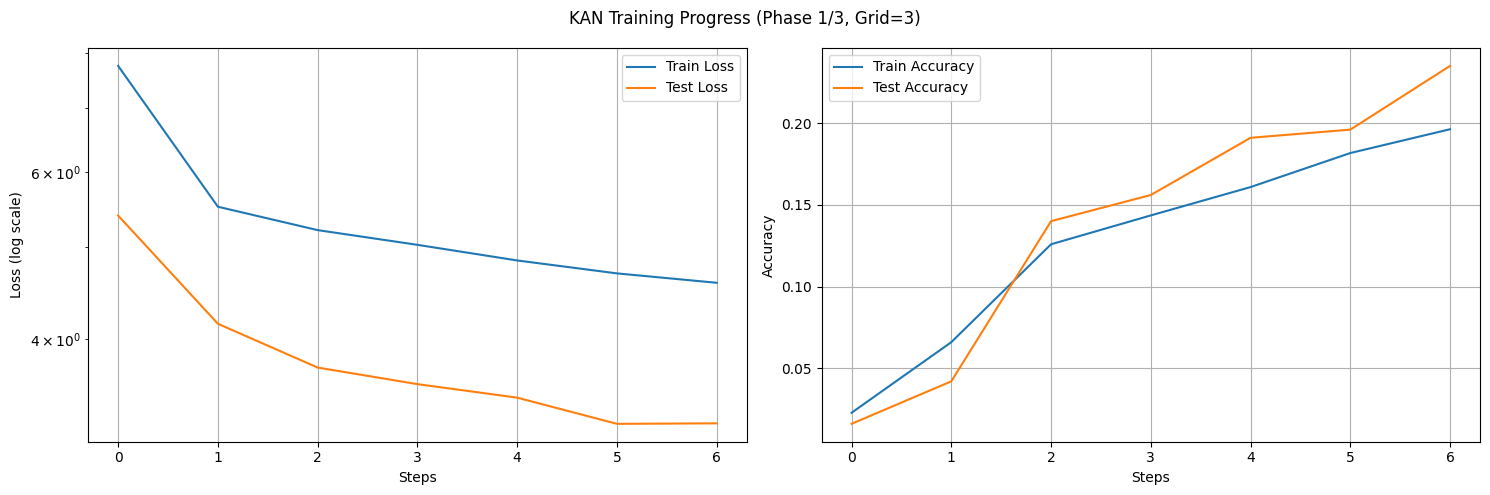

网格点 G=3 训练完成!
训练损失: 4.587658, 测试损失: 3.263369
训练准确率: 0.1962, 测试准确率: 0.2350
RMSE改善! 当前最佳Grid大小: 3, RMSE: 3.263369
模型成功保存到文件夹: /home/jannik/Documents/brain_voxel_data/output/kan_models/kan_brain_model_phase1_grid3_grid3_20250228_180918
阶段 1 网格点 G=3 模型已保存
进行Grid扩展: 3 -> 4
网格扩展成功! 从 3 到 4
当前网格G=4的批量大小: 100000 (总训练样本的1.49%)

-- 网格点 2/24 (G=4), 训练步数: 30 --
获取固定批次，大小: 100000 样本
固定批次获取成功，形状: torch.Size([100000, 341])
Grid 4: 1/30 (3.3%)
步骤 1/30, 训练损失: 7.767797, 测试损失: 4.830882
训练准确率: 0.0438, 测试准确率: 0.0720
Grid 4: 3/30 (10.0%)
Grid 4: 5/30 (16.7%)
步骤 6/30, 训练损失: 5.496981, 测试损失: 3.863544
训练准确率: 0.1078, 测试准确率: 0.1050
Grid 4: 7/30 (23.3%)
Grid 4: 9/30 (30.0%)
Grid 4: 11/30 (36.7%)
步骤 11/30, 训练损失: 5.088508, 测试损失: 3.409946
训练准确率: 0.1475, 测试准确率: 0.1650
Grid 4: 13/30 (43.3%)
Grid 4: 15/30 (50.0%)
步骤 16/30, 训练损失: 4.881196, 测试损失: 3.385919
训练准确率: 0.1737, 测试准确率: 0.1970
Grid 4: 17/30 (56.7%)
Grid 4: 19/30 (63.3%)
Grid 4: 21/30 (70.0%)
步骤 21/30, 训练损失: 4.714292, 测试损失: 3.144500
训练准确率: 0.1980, 测试准确率: 0.2160
Grid

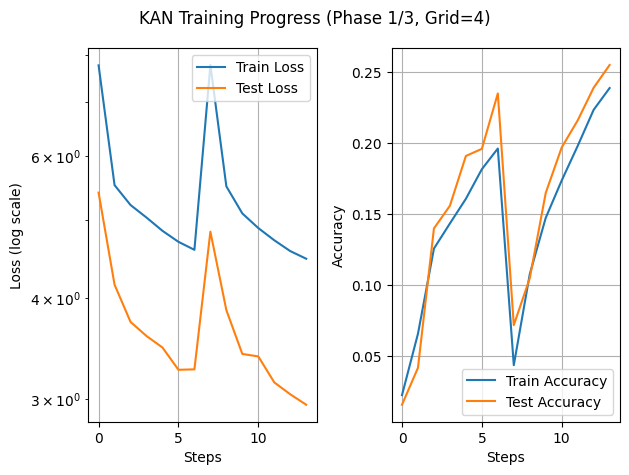

网格点 G=4 训练完成!
训练损失: 4.472613, 测试损失: 2.950558
训练准确率: 0.2388, 测试准确率: 0.2550
RMSE改善! 当前最佳Grid大小: 4, RMSE: 2.950558
进行Grid扩展: 4 -> 5
网格扩展成功! 从 4 到 5
当前网格G=5的批量大小: 100000 (总训练样本的1.49%)

-- 网格点 3/24 (G=5), 训练步数: 30 --
获取固定批次，大小: 100000 样本
固定批次获取成功，形状: torch.Size([100000, 341])
Grid 5: 1/30 (3.3%)
步骤 1/30, 训练损失: 7.678731, 测试损失: 5.135956
训练准确率: 0.0749, 测试准确率: 0.0620
Grid 5: 3/30 (10.0%)
Grid 5: 5/30 (16.7%)
步骤 6/30, 训练损失: 5.423087, 测试损失: 3.689610
训练准确率: 0.1301, 测试准确率: 0.1260
Grid 5: 7/30 (23.3%)
Grid 5: 9/30 (30.0%)
Grid 5: 11/30 (36.7%)
步骤 11/30, 训练损失: 5.000762, 测试损失: 3.416228
训练准确率: 0.1579, 测试准确率: 0.1780
Grid 5: 13/30 (43.3%)
Grid 5: 15/30 (50.0%)
步骤 16/30, 训练损失: 4.787635, 测试损失: 3.182314
训练准确率: 0.2020, 测试准确率: 0.1940
Grid 5: 17/30 (56.7%)
Grid 5: 19/30 (63.3%)
Grid 5: 21/30 (70.0%)
步骤 21/30, 训练损失: 4.618089, 测试损失: 2.980270
训练准确率: 0.2266, 测试准确率: 0.2280
Grid 5: 23/30 (76.7%)
Grid 5: 25/30 (83.3%)
步骤 26/30, 训练损失: 4.486542, 测试损失: 2.855560
训练准确率: 0.2519, 测试准确率: 0.2550
Grid 5: 27/30 (90.0%)
Grid 5: 

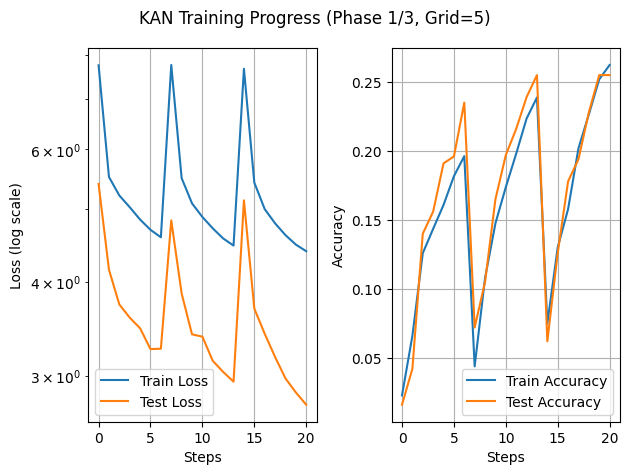

网格点 G=5 训练完成!
训练损失: 4.396352, 测试损失: 2.749767
训练准确率: 0.2623, 测试准确率: 0.2550
RMSE改善! 当前最佳Grid大小: 5, RMSE: 2.749767
进行Grid扩展: 5 -> 6
网格扩展成功! 从 5 到 6
当前网格G=6的批量大小: 100000 (总训练样本的1.49%)

-- 网格点 4/24 (G=6), 训练步数: 30 --
获取固定批次，大小: 100000 样本
固定批次获取成功，形状: torch.Size([100000, 341])
Grid 6: 1/30 (3.3%)
步骤 1/30, 训练损失: 7.706465, 测试损失: 4.775705
训练准确率: 0.0940, 测试准确率: 0.1070
Grid 6: 3/30 (10.0%)
Grid 6: 5/30 (16.7%)
步骤 6/30, 训练损失: 5.380541, 测试损失: 3.664722
训练准确率: 0.1584, 测试准确率: 0.1690
Grid 6: 7/30 (23.3%)
Grid 6: 9/30 (30.0%)
Grid 6: 11/30 (36.7%)
步骤 11/30, 训练损失: 5.033231, 测试损失: 3.193926
训练准确率: 0.1926, 测试准确率: 0.2040
Grid 6: 13/30 (43.3%)
Grid 6: 15/30 (50.0%)
步骤 16/30, 训练损失: 4.787023, 测试损失: 3.027499
训练准确率: 0.2315, 测试准确率: 0.2370
Grid 6: 17/30 (56.7%)
Grid 6: 19/30 (63.3%)
Grid 6: 21/30 (70.0%)
步骤 21/30, 训练损失: 4.581154, 测试损失: 2.951411
训练准确率: 0.2549, 测试准确率: 0.2690
Grid 6: 23/30 (76.7%)
Grid 6: 25/30 (83.3%)
步骤 26/30, 训练损失: 4.452795, 测试损失: 2.755178
训练准确率: 0.2741, 测试准确率: 0.2820
Grid 6: 27/30 (90.0%)
Grid 6: 

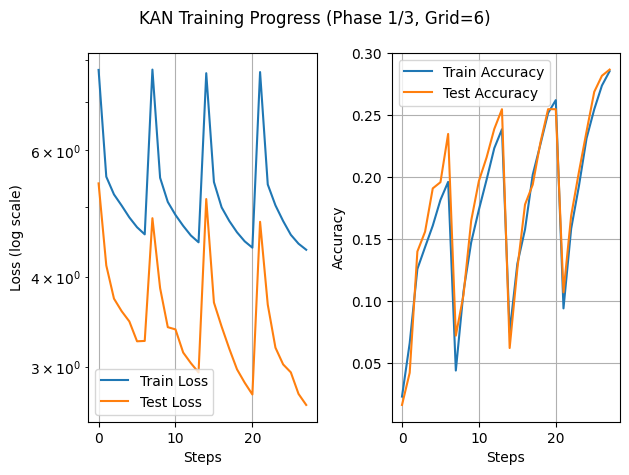

网格点 G=6 训练完成!
训练损失: 4.367286, 测试损失: 2.659472
训练准确率: 0.2857, 测试准确率: 0.2870
RMSE改善! 当前最佳Grid大小: 6, RMSE: 2.659472
进行Grid扩展: 6 -> 7
网格扩展成功! 从 6 到 7
当前网格G=7的批量大小: 100000 (总训练样本的1.49%)

-- 网格点 5/24 (G=7), 训练步数: 30 --
获取固定批次，大小: 100000 样本
固定批次获取成功，形状: torch.Size([100000, 341])
Grid 7: 1/30 (3.3%)
步骤 1/30, 训练损失: 7.180569, 测试损失: 4.273000
训练准确率: 0.0979, 测试准确率: 0.0930
Grid 7: 3/30 (10.0%)
Grid 7: 5/30 (16.7%)
步骤 6/30, 训练损失: 5.454642, 测试损失: 3.337533
训练准确率: 0.1644, 测试准确率: 0.1560
Grid 7: 7/30 (23.3%)
Grid 7: 9/30 (30.0%)
Grid 7: 11/30 (36.7%)
步骤 11/30, 训练损失: 4.956133, 测试损失: 3.089570
训练准确率: 0.2077, 测试准确率: 0.1970
Grid 7: 13/30 (43.3%)
Grid 7: 15/30 (50.0%)
步骤 16/30, 训练损失: 4.715991, 测试损失: 2.895253
训练准确率: 0.2447, 测试准确率: 0.2430
Grid 7: 17/30 (56.7%)
Grid 7: 19/30 (63.3%)
Grid 7: 21/30 (70.0%)
步骤 21/30, 训练损失: 4.551818, 测试损失: 2.794741
训练准确率: 0.2675, 测试准确率: 0.2580
Grid 7: 23/30 (76.7%)
Grid 7: 25/30 (83.3%)
步骤 26/30, 训练损失: 4.435144, 测试损失: 2.705674
训练准确率: 0.2870, 测试准确率: 0.2850
Grid 7: 27/30 (90.0%)
Grid 7: 

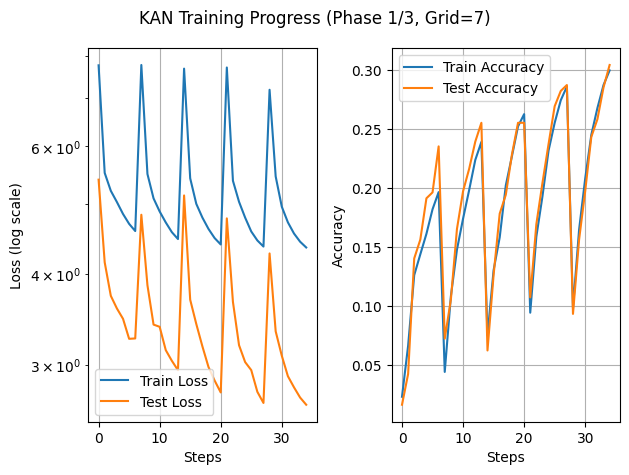

网格点 G=7 训练完成!
训练损失: 4.354599, 测试损失: 2.644583
训练准确率: 0.2994, 测试准确率: 0.3040
RMSE改善! 当前最佳Grid大小: 7, RMSE: 2.644583
进行Grid扩展: 7 -> 8
网格扩展成功! 从 7 到 8
当前网格G=8的批量大小: 100000 (总训练样本的1.49%)

-- 网格点 6/24 (G=8), 训练步数: 30 --
获取固定批次，大小: 100000 样本
固定批次获取成功，形状: torch.Size([100000, 341])
Grid 8: 1/30 (3.3%)
步骤 1/30, 训练损失: 7.302070, 测试损失: 4.235224
训练准确率: 0.1033, 测试准确率: 0.1010
Grid 8: 3/30 (10.0%)
Grid 8: 5/30 (16.7%)
训练网格点 G=8 失败: CUDA out of memory. Tried to allocate 1.53 GiB. GPU 0 has a total capacity of 21.95 GiB of which 1.54 GiB is free. Including non-PyTorch memory, this process has 20.40 GiB memory in use. Of the allocated memory 20.03 GiB is allocated by PyTorch, and 144.36 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)
进行Grid扩展: 8 -> 9
网格扩展成功! 从 8 到 9
当前网格G=

Traceback (most recent call last):
  File "/var/tmp/ipykernel_219540/280814210.py", line 228, in train_kan_with_fixed_batch_per_grid
    loss.backward()
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/_tensor.py", line 626, in backward
    torch.autograd.backward(
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/autograd/__init__.py", line 347, in backward
    _engine_run_backward(
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/autograd/graph.py", line 823, in _engine_run_backward
    return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
torch.OutOfMemoryError: CUDA out of memory. Tried to allocate 1.53 GiB. GPU 0 has a total capacity of 21.95 GiB of which 1.54 GiB is free. Including non-PyTorch memory, this process has 20.40 GiB memory in use. Of the allocated memory 20.03 GiB is allocated by PyTorch, and 144.36 MiB is reserved by PyTorch but unallocated. If reserved but unallocated m

网格扩展成功! 从 9 到 10
当前网格G=10的批量大小: 100000 (总训练样本的1.49%)

-- 网格点 8/24 (G=10), 训练步数: 30 --
获取固定批次，大小: 100000 样本
固定批次获取成功，形状: torch.Size([100000, 341])
Grid 10: 1/30 (3.3%)
训练网格点 G=10 失败: CUDA out of memory. Tried to allocate 1.91 GiB. GPU 0 has a total capacity of 21.95 GiB of which 1.25 GiB is free. Including non-PyTorch memory, this process has 20.69 GiB memory in use. Of the allocated memory 20.33 GiB is allocated by PyTorch, and 138.58 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)
进行Grid扩展: 10 -> 11
网格扩展成功! 从 10 到 11
当前网格G=11的批量大小: 100000 (总训练样本的1.49%)

-- 网格点 9/24 (G=11), 训练步数: 30 --
获取固定批次，大小: 100000 样本
固定批次获取成功，形状: torch.Size([100000, 341])
Grid 11: 1/30 (3.3%)


Traceback (most recent call last):
  File "/var/tmp/ipykernel_219540/280814210.py", line 217, in train_kan_with_fixed_batch_per_grid
    outputs = model(X_batch)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1739, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1750, in _call_impl
    return forward_call(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/fastkan/fastkan.py", line 144, in forward
    x = layer(x)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1739, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1750, in _call_impl
    return forward_call(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/fastkan/fastkan.p

训练网格点 G=11 失败: CUDA out of memory. Tried to allocate 2.10 GiB. GPU 0 has a total capacity of 21.95 GiB of which 822.12 MiB is free. Including non-PyTorch memory, this process has 21.14 GiB memory in use. Of the allocated memory 20.78 GiB is allocated by PyTorch, and 140.58 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)
进行Grid扩展: 11 -> 12
网格扩展成功! 从 11 到 12
当前网格G=12的批量大小: 100000 (总训练样本的1.49%)

-- 网格点 10/24 (G=12), 训练步数: 30 --
获取固定批次，大小: 100000 样本
固定批次获取成功，形状: torch.Size([100000, 341])
Grid 12: 1/30 (3.3%)


...

Traceback (most recent call last):
  File "/var/tmp/ipykernel_219540/280814210.py", line 217, in train_kan_with_fixed_batch_per_grid
    outputs = model(X_batch)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1739, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1750, in _call_impl
    return forward_call(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/fastkan/fastkan.py", line 144, in forward
    x = layer(x)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1739, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1750, in _call_impl
    return forward_call(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/fastkan/fastkan.p

网格扩展成功! 从 27 到 29
当前网格G=29的批量大小: 100000 (总训练样本的1.49%)

-- 网格点 22/24 (G=29), 训练步数: 30 --
获取固定批次，大小: 100000 样本
固定批次获取成功，形状: torch.Size([100000, 341])
Grid 29: 1/30 (3.3%)
训练网格点 G=29 失败: CUDA out of memory. Tried to allocate 3.69 GiB. GPU 0 has a total capacity of 21.95 GiB of which 2.37 GiB is free. Including non-PyTorch memory, this process has 19.58 GiB memory in use. Of the allocated memory 19.23 GiB is allocated by PyTorch, and 125.54 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)
进行Grid扩展: 29 -> 31
网格扩展成功! 从 29 到 31
当前网格G=31的批量大小: 100000 (总训练样本的1.49%)

-- 网格点 23/24 (G=31), 训练步数: 30 --
获取固定批次，大小: 100000 样本
固定批次获取成功，形状: torch.Size([100000, 341])
Grid 31: 1/30 (3.3%)


Traceback (most recent call last):
  File "/var/tmp/ipykernel_219540/280814210.py", line 217, in train_kan_with_fixed_batch_per_grid
    outputs = model(X_batch)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1739, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1750, in _call_impl
    return forward_call(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/fastkan/fastkan.py", line 144, in forward
    x = layer(x)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1739, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1750, in _call_impl
    return forward_call(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/fastkan/fastkan.p

训练网格点 G=31 失败: CUDA out of memory. Tried to allocate 3.94 GiB. GPU 0 has a total capacity of 21.95 GiB of which 2.07 GiB is free. Including non-PyTorch memory, this process has 19.87 GiB memory in use. Of the allocated memory 19.49 GiB is allocated by PyTorch, and 160.31 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)
进行Grid扩展: 31 -> 33
网格扩展成功! 从 31 到 33
当前网格G=33的批量大小: 100000 (总训练样本的1.49%)

-- 网格点 24/24 (G=33), 训练步数: 30 --
获取固定批次，大小: 100000 样本
固定批次获取成功，形状: torch.Size([100000, 341])
Grid 33: 1/30 (3.3%)
训练网格点 G=33 失败: CUDA out of memory. Tried to allocate 4.19 GiB. GPU 0 has a total capacity of 21.95 GiB of which 1.82 GiB is free. Including non-PyTorch memory, this process has 20.12 GiB memory in use. Of the allocated memory 19.75 GiB is allocated by P

Traceback (most recent call last):
  File "/var/tmp/ipykernel_219540/280814210.py", line 217, in train_kan_with_fixed_batch_per_grid
    outputs = model(X_batch)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1739, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1750, in _call_impl
    return forward_call(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/fastkan/fastkan.py", line 144, in forward
    x = layer(x)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1739, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1750, in _call_impl
    return forward_call(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/fastkan/fastkan.p

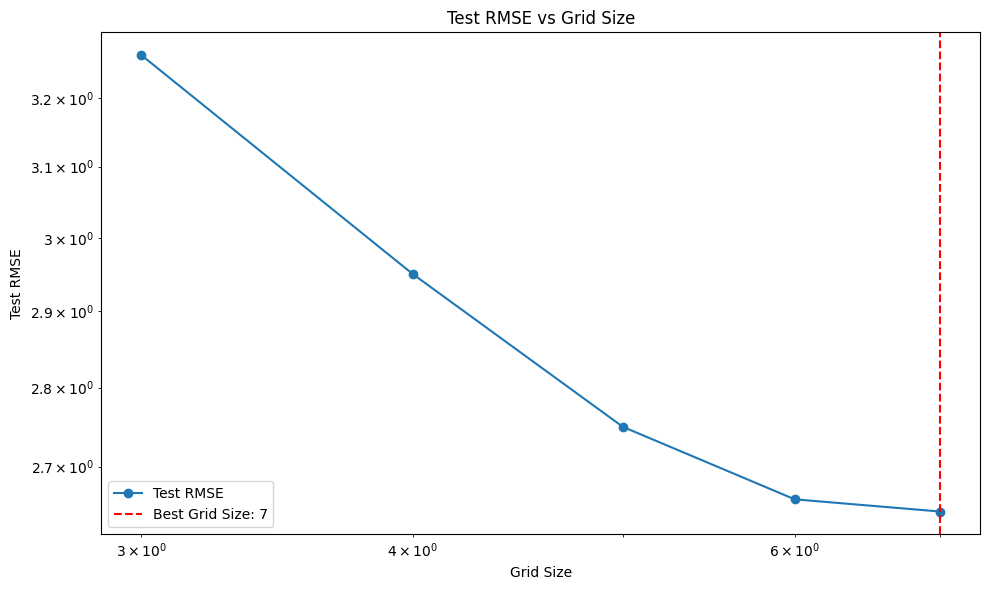


==== 主阶段 2/3 ====
当前阶段学习率: 0.0005
网格序列: [36, 39, 42, 45, 49, 52, 56, 61, 65, 70, 76, 82, 88, 95, 102, 110, 118, 127, 137, 147, 159, 171, 184]
每个网格点训练步数: 20
进行Grid扩展: 33 -> 36
网格扩展成功! 从 33 到 36
当前网格G=36的批量大小: 96105 (总训练样本的1.43%)

-- 网格点 1/23 (G=36), 训练步数: 20 --
获取固定批次，大小: 96105 样本
固定批次获取成功，形状: torch.Size([96105, 341])
Grid 36: 1/20 (5.0%)
训练网格点 G=36 失败: CUDA out of memory. Tried to allocate 4.40 GiB. GPU 0 has a total capacity of 21.95 GiB of which 1.60 GiB is free. Including non-PyTorch memory, this process has 20.34 GiB memory in use. Of the allocated memory 19.94 GiB is allocated by PyTorch, and 172.60 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)
进行Grid扩展: 36 -> 39
网格扩展成功! 从 36 到 39
当前网格G=39的批量大小: 96105 (总训练样本的1.43%)

-- 网格点 2/23 (G=39), 训练步数: 2

Traceback (most recent call last):
  File "/var/tmp/ipykernel_219540/280814210.py", line 217, in train_kan_with_fixed_batch_per_grid
    outputs = model(X_batch)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1739, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1750, in _call_impl
    return forward_call(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/fastkan/fastkan.py", line 144, in forward
    x = layer(x)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1739, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1750, in _call_impl
    return forward_call(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/fastkan/fastkan.p

网格扩展成功! 从 39 到 42
当前网格G=42的批量大小: 96105 (总训练样本的1.43%)

-- 网格点 3/23 (G=42), 训练步数: 20 --
获取固定批次，大小: 96105 样本
固定批次获取成功，形状: torch.Size([96105, 341])
Grid 42: 1/20 (5.0%)
训练网格点 G=42 失败: CUDA out of memory. Tried to allocate 5.13 GiB. GPU 0 has a total capacity of 21.95 GiB of which 862.12 MiB is free. Including non-PyTorch memory, this process has 21.10 GiB memory in use. Of the allocated memory 20.69 GiB is allocated by PyTorch, and 187.32 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)
进行Grid扩展: 42 -> 45
网格扩展成功! 从 42 到 45
当前网格G=45的批量大小: 96105 (总训练样本的1.43%)

-- 网格点 4/23 (G=45), 训练步数: 20 --
获取固定批次，大小: 96105 样本
固定批次获取成功，形状: torch.Size([96105, 341])
Grid 45: 1/20 (5.0%)


Traceback (most recent call last):
  File "/var/tmp/ipykernel_219540/280814210.py", line 217, in train_kan_with_fixed_batch_per_grid
    outputs = model(X_batch)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1739, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1750, in _call_impl
    return forward_call(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/fastkan/fastkan.py", line 144, in forward
    x = layer(x)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1739, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1750, in _call_impl
    return forward_call(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/fastkan/fastkan.p

训练网格点 G=45 失败: CUDA out of memory. Tried to allocate 5.49 GiB. GPU 0 has a total capacity of 21.95 GiB of which 502.12 MiB is free. Including non-PyTorch memory, this process has 21.45 GiB memory in use. Of the allocated memory 21.07 GiB is allocated by PyTorch, and 164.69 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)
进行Grid扩展: 45 -> 49
网格扩展成功! 从 45 到 49
当前网格G=49的批量大小: 96105 (总训练样本的1.43%)

-- 网格点 5/23 (G=49), 训练步数: 20 --
获取固定批次，大小: 96105 样本
固定批次获取成功，形状: torch.Size([96105, 341])
Grid 49: 1/20 (5.0%)
训练网格点 G=49 失败: CUDA out of memory. Tried to allocate 5.98 GiB. GPU 0 has a total capacity of 21.95 GiB of which 5.96 GiB is free. Including non-PyTorch memory, this process has 15.98 GiB memory in use. Of the allocated memory 15.58 GiB is allocated by PyT

...

Traceback (most recent call last):
  File "/var/tmp/ipykernel_219540/280814210.py", line 217, in train_kan_with_fixed_batch_per_grid
    outputs = model(X_batch)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1739, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1750, in _call_impl
    return forward_call(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/fastkan/fastkan.py", line 144, in forward
    x = layer(x)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1739, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1750, in _call_impl
    return forward_call(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/fastkan/fastkan.p

网格扩展成功! 从 159 到 171
当前网格G=171的批量大小: 96105 (总训练样本的1.43%)

-- 网格点 22/23 (G=171), 训练步数: 20 --
获取固定批次，大小: 96105 样本
固定批次获取成功，形状: torch.Size([96105, 341])
Grid 171: 1/20 (5.0%)
训练网格点 G=171 失败: CUDA out of memory. Tried to allocate 20.88 GiB. GPU 0 has a total capacity of 21.95 GiB of which 5.71 GiB is free. Including non-PyTorch memory, this process has 16.24 GiB memory in use. Of the allocated memory 15.87 GiB is allocated by PyTorch, and 142.79 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)
进行Grid扩展: 171 -> 184


Traceback (most recent call last):
  File "/var/tmp/ipykernel_219540/280814210.py", line 217, in train_kan_with_fixed_batch_per_grid
    outputs = model(X_batch)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1739, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1750, in _call_impl
    return forward_call(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/fastkan/fastkan.py", line 144, in forward
    x = layer(x)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1739, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1750, in _call_impl
    return forward_call(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/fastkan/fastkan.p

网格扩展成功! 从 171 到 184
当前网格G=184的批量大小: 96105 (总训练样本的1.43%)

-- 网格点 23/23 (G=184), 训练步数: 20 --
获取固定批次，大小: 96105 样本
固定批次获取成功，形状: torch.Size([96105, 341])
Grid 184: 1/20 (5.0%)
训练网格点 G=184 失败: CUDA out of memory. Tried to allocate 22.46 GiB. GPU 0 has a total capacity of 21.95 GiB of which 5.69 GiB is free. Including non-PyTorch memory, this process has 16.26 GiB memory in use. Of the allocated memory 15.90 GiB is allocated by PyTorch, and 131.15 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)


Traceback (most recent call last):
  File "/var/tmp/ipykernel_219540/280814210.py", line 217, in train_kan_with_fixed_batch_per_grid
    outputs = model(X_batch)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1739, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1750, in _call_impl
    return forward_call(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/fastkan/fastkan.py", line 144, in forward
    x = layer(x)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1739, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1750, in _call_impl
    return forward_call(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/fastkan/fastkan.p

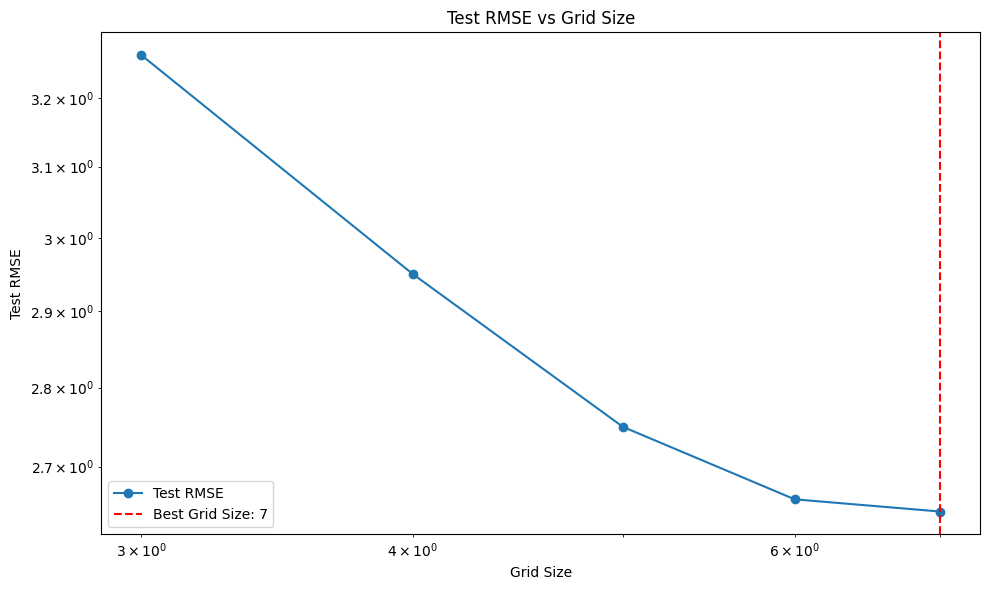


==== 主阶段 3/3 ====
当前阶段学习率: 0.0002
网格序列: [198, 213, 229, 247, 266, 286, 308, 331, 357, 384, 413, 445, 479, 515, 555, 597, 643, 692, 745, 802, 863, 929, 1000]
每个网格点训练步数: 10
进行Grid扩展: 184 -> 198
网格扩展成功! 从 184 到 198
当前网格G=198的批量大小: 48052 (总训练样本的0.71%)

-- 网格点 1/23 (G=198), 训练步数: 10 --
获取固定批次，大小: 48052 样本
固定批次获取成功，形状: torch.Size([48052, 341])
Grid 198: 1/10 (10.0%)
训练网格点 G=198 失败: CUDA out of memory. Tried to allocate 12.09 GiB. GPU 0 has a total capacity of 21.95 GiB of which 5.76 GiB is free. Including non-PyTorch memory, this process has 16.18 GiB memory in use. Of the allocated memory 15.80 GiB is allocated by PyTorch, and 161.06 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)
进行Grid扩展: 198 -> 213


Traceback (most recent call last):
  File "/var/tmp/ipykernel_219540/280814210.py", line 217, in train_kan_with_fixed_batch_per_grid
    outputs = model(X_batch)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1739, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1750, in _call_impl
    return forward_call(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/fastkan/fastkan.py", line 144, in forward
    x = layer(x)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1739, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1750, in _call_impl
    return forward_call(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/fastkan/fastkan.p

网格扩展成功! 从 198 到 213
当前网格G=213的批量大小: 48052 (总训练样本的0.71%)

-- 网格点 2/23 (G=213), 训练步数: 10 --
获取固定批次，大小: 48052 样本
固定批次获取成功，形状: torch.Size([48052, 341])
Grid 213: 1/10 (10.0%)
训练网格点 G=213 失败: CUDA out of memory. Tried to allocate 13.00 GiB. GPU 0 has a total capacity of 21.95 GiB of which 5.72 GiB is free. Including non-PyTorch memory, this process has 16.22 GiB memory in use. Of the allocated memory 15.83 GiB is allocated by PyTorch, and 164.35 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)
进行Grid扩展: 213 -> 229


Traceback (most recent call last):
  File "/var/tmp/ipykernel_219540/280814210.py", line 217, in train_kan_with_fixed_batch_per_grid
    outputs = model(X_batch)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1739, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1750, in _call_impl
    return forward_call(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/fastkan/fastkan.py", line 144, in forward
    x = layer(x)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1739, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1750, in _call_impl
    return forward_call(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/fastkan/fastkan.p

网格扩展成功! 从 213 到 229
当前网格G=229的批量大小: 48052 (总训练样本的0.71%)

-- 网格点 3/23 (G=229), 训练步数: 10 --
获取固定批次，大小: 48052 样本
固定批次获取成功，形状: torch.Size([48052, 341])
Grid 229: 1/10 (10.0%)
训练网格点 G=229 失败: CUDA out of memory. Tried to allocate 13.98 GiB. GPU 0 has a total capacity of 21.95 GiB of which 5.72 GiB is free. Including non-PyTorch memory, this process has 16.22 GiB memory in use. Of the allocated memory 15.87 GiB is allocated by PyTorch, and 125.12 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)
进行Grid扩展: 229 -> 247


...

Traceback (most recent call last):
  File "/var/tmp/ipykernel_219540/280814210.py", line 217, in train_kan_with_fixed_batch_per_grid
    outputs = model(X_batch)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1739, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1750, in _call_impl
    return forward_call(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/fastkan/fastkan.py", line 144, in forward
    x = layer(x)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1739, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1750, in _call_impl
    return forward_call(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/fastkan/fastkan.p

网格扩展成功! 从 863 到 929
当前网格G=929的批量大小: 48052 (总训练样本的0.71%)

-- 网格点 22/23 (G=929), 训练步数: 10 --
获取固定批次，大小: 48052 样本
固定批次获取成功，形状: torch.Size([48052, 341])
Grid 929: 1/10 (10.0%)
训练网格点 G=929 失败: CUDA out of memory. Tried to allocate 56.71 GiB. GPU 0 has a total capacity of 21.95 GiB of which 4.06 GiB is free. Including non-PyTorch memory, this process has 17.88 GiB memory in use. Of the allocated memory 17.54 GiB is allocated by PyTorch, and 116.51 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)
进行Grid扩展: 929 -> 1000


Traceback (most recent call last):
  File "/var/tmp/ipykernel_219540/280814210.py", line 217, in train_kan_with_fixed_batch_per_grid
    outputs = model(X_batch)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1739, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1750, in _call_impl
    return forward_call(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/fastkan/fastkan.py", line 144, in forward
    x = layer(x)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1739, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1750, in _call_impl
    return forward_call(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/fastkan/fastkan.p

网格扩展成功! 从 929 到 1000
当前网格G=1000的批量大小: 48052 (总训练样本的0.71%)

-- 网格点 23/23 (G=1000), 训练步数: 10 --
获取固定批次，大小: 48052 样本
固定批次获取成功，形状: torch.Size([48052, 341])
Grid 1000: 1/10 (10.0%)
训练网格点 G=1000 失败: CUDA out of memory. Tried to allocate 61.04 GiB. GPU 0 has a total capacity of 21.95 GiB of which 3.87 GiB is free. Including non-PyTorch memory, this process has 18.07 GiB memory in use. Of the allocated memory 17.71 GiB is allocated by PyTorch, and 143.12 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)


Traceback (most recent call last):
  File "/var/tmp/ipykernel_219540/280814210.py", line 217, in train_kan_with_fixed_batch_per_grid
    outputs = model(X_batch)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1739, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1750, in _call_impl
    return forward_call(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/fastkan/fastkan.py", line 144, in forward
    x = layer(x)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1739, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1750, in _call_impl
    return forward_call(*args, **kwargs)
  File "/opt/conda/envs/fastkan/lib/python3.9/site-packages/fastkan/fastkan.p

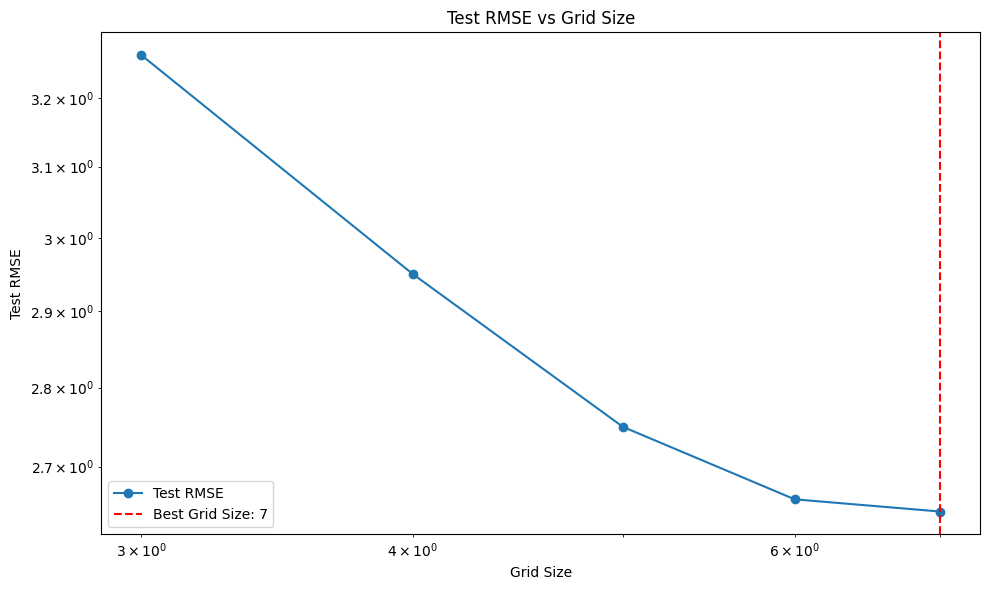


训练完成！总用时: 114.98 秒
最终训练准确率: 0.2994
最终测试准确率: 0.3040

对验证集进行最终评估...


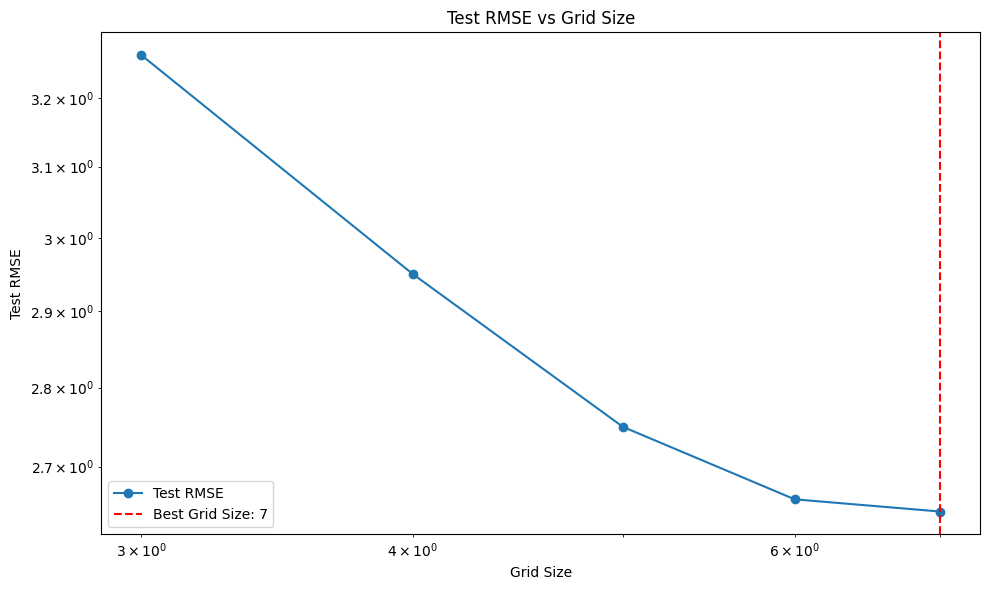

模型成功保存到文件夹: /home/jannik/Documents/brain_voxel_data/output/kan_models/kan_brain_final_model_grid1000_20250228_181103
最终模型已保存，准确率: 0.0630
总训练时间: 117.64 秒 (约 0.03 小时)
训练结果数据已保存到: /home/jannik/Documents/brain_voxel_data/output/kan_models/training_results_exponential_grid.npz


NameError: name 'rmse_monitor' is not defined

/opt/conda/envs/fastkan/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/envs/fastkan/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/envs/fastkan/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/envs/fastkan/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/envs/fastkan/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 21644 (\N{CJK UNIFIED IDEOGRAPH-548C}) missing from c

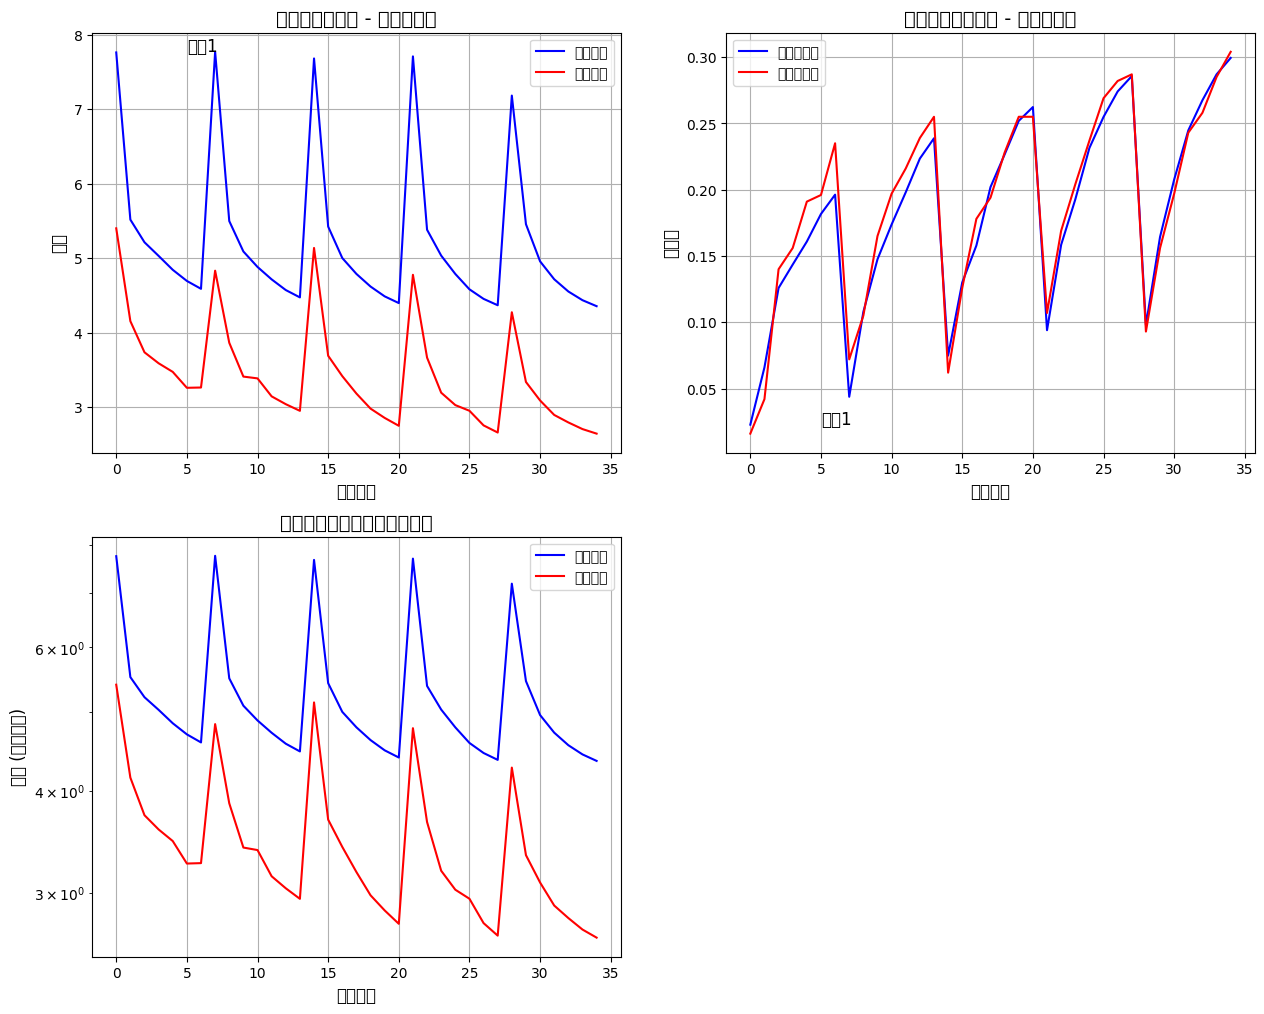

In [12]:
# 使用指数型网格增长的训练函数
# !pip install ipywidgets  tqdm-4.67.1
from tqdm.notebook import tqdm
from datetime import datetime

def train_kan_with_fixed_batch_per_grid(batch_fraction=None, min_batch_size=1000, max_batch_size=100000):
    """
    Training KAN with exponential grid growth but using a fixed batch for all steps within each grid size.
    Only changes the batch when extending to a new grid size.
    
    Parameters:
    -----------
    batch_fraction : float or None
        If provided, uses this fraction of the training data for each grid size.
        If None, divides the dataset by the number of grid points (default behavior).
    min_batch_size : int
        Minimum batch size to use, regardless of calculations.
    max_batch_size : int
        Maximum batch size to use, to prevent memory issues.
    """
    print(f"开始训练KAN模型，使用固定批次的指数型网格增长策略，总网格点数: {len(grid_sequence)}")
    print(f"网络结构: {network_structure}, 总训练步数: {total_steps}")
    start_time = time.time()
    
    # 初始化RMSE监控器
    rmse_monitor = RMSEMonitor(patience=5, min_delta=1e-5)
    
    # 准备追踪变量
    train_losses = []
    test_losses = []
    train_accs = []
    test_accs = []
    used_grid_sizes = []
    
    # 创建初始KAN模型 - 从最小的网格开始，使用指定的网络结构
    model = fastkan.FastKAN(
        layers_hidden=network_structure,
        num_grids=grid_sequence[0]
    )

    # 将模型移至指定设备
    model = model.to(device)
    # 打印模型信息
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"创建的KAN模型 - 结构: {network_structure}")
    print(f"参数数量: {total_params:,}, 初始网格大小: {grid_sequence[0]}")
    
    # 准备用于绘图的实时显示
    plt.figure(figsize=(15, 5))
    plt.ion()  # 打开交互模式
    
    # 保存阶段边界点，用于后续可视化
    phase_boundaries = []
    current_step_count = 0
    
    # 定义评估函数 - 使用小批量
    def train_acc():
        with torch.no_grad():
            # 从训练集获取10000个样本
            X_batch, y_batch = get_train_batch(10000)
            
            outputs = model(X_batch)
            pred = torch.argmax(outputs, dim=1)
            true = torch.argmax(y_batch, dim=1)
            result = torch.mean((pred == true).float())
            return result
    
    def test_acc():
        with torch.no_grad():
            # 为评估使用小批量
            batch_size = 200  # 使用更小的批量
            n_batches = (full_dataset['test_input'].shape[0] + batch_size - 1) // batch_size
            correct = 0
            total = 0
            
            for i in range(n_batches):
                start_idx = i * batch_size
                end_idx = min((i + 1) * batch_size, full_dataset['test_input'].shape[0])
                
                batch_input = full_dataset['test_input'][start_idx:end_idx]
                batch_label = full_dataset['test_label'][start_idx:end_idx]
                
                outputs = model(batch_input)
                pred = torch.argmax(outputs, dim=1)
                true = torch.argmax(batch_label, dim=1)
                
                correct += torch.sum(pred == true).item()
                total += batch_input.shape[0]
            
            return torch.tensor(correct / total, device=device)
    
    # 获取模型当前的网格大小的辅助函数
    def get_grid_size(model):
        return model.layers[0].rbf.num_grids
    
    # 循环训练每个网格阶段
    for phase_idx in range(3):  # 分为3个主要阶段
        print(f"\n==== 主阶段 {phase_idx+1}/3 ====")
        phase_grid_seq = phase_grid_sequences[phase_idx]
        steps_per_grid = steps_per_phase[phase_idx]
        
        # 根据阶段调整学习率
        if phase_idx == 0:
            current_lr = learning_rate       # 第1阶段使用标准学习率
        elif phase_idx == 1:
            current_lr = learning_rate / 2   # 第2阶段减半学习率
        else:
            current_lr = learning_rate / 5   # 第3阶段使用更小学习率
        
        print(f"当前阶段学习率: {current_lr}")
        print(f"网格序列: {phase_grid_seq}")
        print(f"每个网格点训练步数: {steps_per_grid}")
        
        # 循环训练每个网格点
        for grid_idx, current_grid in enumerate(phase_grid_seq):
            # 如果不是第一个网格点，进行grid扩展
            if not (phase_idx == 0 and grid_idx == 0):
                previous_grid = get_grid_size(model)  # 获取当前模型的网格大小
                if previous_grid != current_grid:  # 只有当网格大小变化时才进行扩展
                    print(f"进行Grid扩展: {previous_grid} -> {current_grid}")
                    try:
                        # 为网格扩展使用小批量数据
                        X_sample, _ = get_train_batch(100)  # 只需要特征，不需要标签
                        
                        # 创建一个新的模型，使用新的网格大小
                        old_model = model  # 保存旧模型引用
                        
                        # 创建新模型
                        model = fastkan.FastKAN(
                            layers_hidden=network_structure,
                            num_grids=current_grid
                        ).to(device)
                        
                        # 传输基础层权重（非网格相关部分）
                        for i, (old_layer, new_layer) in enumerate(zip(old_model.layers, model.layers)):
                            if hasattr(old_layer, 'base_linear') and hasattr(new_layer, 'base_linear'):
                                new_layer.base_linear.weight.data.copy_(old_layer.base_linear.weight.data)
                                if hasattr(old_layer.base_linear, 'bias') and old_layer.base_linear.bias is not None:
                                    new_layer.base_linear.bias.data.copy_(old_layer.base_linear.bias.data)
                        
                        # 注意：无法直接传输spline权重，因为它们依赖于网格大小
                        
                        print(f"网格扩展成功! 从 {previous_grid} 到 {current_grid}")
                    except Exception as e:
                        print(f"网格扩展失败: {str(e)}")
                        import traceback
                        traceback.print_exc()
            
            # 记录阶段边界，用于后续可视化
            if grid_idx == 0 and phase_idx > 0:
                phase_boundaries.append(current_step_count)
            
            # 计算训练数据集的总大小
            total_train_samples = X_train1.shape[0]
            total_grid_points = len(grid_sequence)
            
            # 为当前网格点调整批量大小
            if batch_fraction is not None:
                # 使用用户提供的比例
                current_batch_size = int(total_train_samples * batch_fraction)
            else:
                # 默认策略：将数据平均分配给网格点
                # 按照网格变细时减小批量大小的策略
                if phase_idx == 0:
                    # 第一阶段使用较大的批量
                    samples_per_grid = total_train_samples // total_grid_points * 2
                elif phase_idx == 1:
                    # 第二阶段使用中等批量
                    samples_per_grid = total_train_samples // total_grid_points
                else:
                    # 第三阶段使用较小批量
                    samples_per_grid = total_train_samples // total_grid_points // 2
                    
                current_batch_size = samples_per_grid
            
            # 确保批量大小在合理范围内
            current_batch_size = max(min_batch_size, min(current_batch_size, max_batch_size))
            
            print(f"当前网格G={current_grid}的批量大小: {current_batch_size} (总训练样本的{current_batch_size/total_train_samples*100:.2f}%)")
                    
            # 训练当前网格点
            print(f"\n-- 网格点 {grid_idx+1}/{len(phase_grid_seq)} (G={current_grid}), 训练步数: {steps_per_grid} --")
                    
            try:
                # 提高正则化系数，特别是在后期网格扩展阶段
                if phase_idx == 0:
                    current_lamb = 0.005  # 大幅增加初始阶段正则化强度
                elif phase_idx == 1:
                    current_lamb = 0.002  # 中间阶段仍保持较高强度
                else:
                    current_lamb = 0.001  # 最后阶段也保持足够强度

                # 自定义训练循环 - 在每个网格大小中使用固定的数据批次
                train_loss_list = []
                test_loss_list = []
                train_acc_list = []
                test_acc_list = []
               
                # 为当前网格点获取一个固定批次，这是本方法的核心修改点
                print(f"获取固定批次，大小: {current_batch_size} 样本")
                X_fixed_batch, y_fixed_batch = get_train_batch(current_batch_size)
                print(f"固定批次获取成功，形状: {X_fixed_batch.shape}")
               
                criterion = torch.nn.CrossEntropyLoss()
                optimizer = torch.optim.Adam(model.parameters(), lr=current_lr)
               
                for step in range(steps_per_grid):
                    if step % 2 == 0 or step == steps_per_grid - 1:
                        print(f"Grid {current_grid}: {step+1}/{steps_per_grid} ({(step+1)/steps_per_grid*100:.1f}%)")
                
                    # 使用之前获取的固定批次，而不是每步获取新批次
                    X_batch, y_batch = X_fixed_batch, y_fixed_batch
                    
                    # 前向传播
                    optimizer.zero_grad()
                    outputs = model(X_batch)
                    loss = criterion(outputs, y_batch)
                    
                    # 添加正则化
                    if current_lamb > 0:
                        l2_reg = 0
                        for param in model.parameters():
                            l2_reg += torch.norm(param)
                        loss += current_lamb * l2_reg
                    
                    # 反向传播和优化
                    loss.backward()
                    optimizer.step()
                    
                    # 每5步评估一次性能
                    if step % 5 == 0 or step == steps_per_grid - 1:
                        with torch.no_grad():
                            # 计算当前固定批次的训练准确率，而不是从全部训练数据中随机抽样
                            with torch.no_grad():
                                outputs = model(X_fixed_batch)
                                pred = torch.argmax(outputs, dim=1)
                                true = torch.argmax(y_fixed_batch, dim=1)
                                train_acc_val = torch.mean((pred == true).float()).item()
                            
                            # 计算测试准确率
                            test_acc_val = test_acc().item()
                            
                            # 用同样的批次评估测试损失
                            test_batch_input = full_dataset['test_input'][:100]  # 使用前100个测试样本
                            test_batch_label = full_dataset['test_label'][:100]
                            test_outputs = model(test_batch_input)
                            test_loss = criterion(test_outputs, test_batch_label).item()
                            
                            # 记录
                            train_loss_list.append(loss.item())
                            test_loss_list.append(test_loss)
                            train_acc_list.append(train_acc_val)
                            test_acc_list.append(test_acc_val)
                            
                            print(f"步骤 {step+1}/{steps_per_grid}, 训练损失: {loss.item():.6f}, 测试损失: {test_loss:.6f}")
                            print(f"训练准确率: {train_acc_val:.4f}, 测试准确率: {test_acc_val:.4f}")
                
                # 模拟results格式与model.fit兼容
                results = {
                    'train_loss': train_loss_list,
                    'test_loss': test_loss_list,
                    'train_acc': train_acc_list,
                    'test_acc': test_acc_list
                }
                    
                # 记录训练结果
                train_losses.extend(results['train_loss'])
                test_losses.extend(results['test_loss'])
                train_accs.extend(results['train_acc'])
                test_accs.extend(results['test_acc'])
                used_grid_sizes.extend([current_grid] * len(results['train_loss']))
                
                # 更新步数计数器
                current_step_count += steps_per_grid
                
                # 更新并显示训练进度图
                plt.clf()
                plt.subplot(1, 2, 1)
                plt.semilogy(train_losses, label='Train Loss')
                plt.semilogy(test_losses, label='Test Loss')
                
                # 在图上标记阶段分界点
                for boundary in phase_boundaries:
                    if boundary < len(train_losses):
                        plt.axvline(x=boundary, color='r', linestyle='--')
                
                plt.xlabel('Steps')
                plt.ylabel('Loss (log scale)')
                plt.legend()
                plt.grid(True)

                plt.subplot(1, 2, 2)
                plt.plot(train_accs, label='Train Accuracy')
                plt.plot(test_accs, label='Test Accuracy')
                
                # 在图上标记阶段分界点
                for boundary in phase_boundaries:
                    if boundary < len(train_accs):
                        plt.axvline(x=boundary, color='r', linestyle='--')
                
                plt.xlabel('Steps')
                plt.ylabel('Accuracy')
                plt.legend()
                plt.grid(True)

                plt.suptitle(f'KAN Training Progress (Phase {phase_idx+1}/3, Grid={current_grid})')
                plt.tight_layout()
                plt.draw()
                plt.pause(0.1)
                
                # 打印当前网格点的结果
                print(f"网格点 G={current_grid} 训练完成!")
                print(f"训练损失: {results['train_loss'][-1]:.6f}, 测试损失: {results['test_loss'][-1]:.6f}")
                print(f"训练准确率: {results['train_acc'][-1]:.4f}, 测试准确率: {results['test_acc'][-1]:.4f}")
                
                # 更新RMSE监控器
                test_rmse = results['test_loss'][-1]  # 使用测试损失作为RMSE的代理
                monitor_result = rmse_monitor.update(current_grid, test_rmse)
                
                # 打印监控结果
                if monitor_result["status"] == "improvement":
                    print(f"RMSE改善! 当前最佳Grid大小: {monitor_result['best_grid_size']}, RMSE: {monitor_result['best_rmse']:.6f}")
                elif monitor_result["status"] == "no_improvement":
                    print(f"RMSE无改善，已连续{monitor_result['no_improvement_count']}次，耐心值剩余: {rmse_monitor.patience - monitor_result['no_improvement_count']}")
                
                # 每个阶段结束时或者每10个网格点保存一次模型
                if grid_idx == len(phase_grid_seq) - 1 or grid_idx % 10 == 0:
                    try:
                        model_folder_base = os.path.join(export_path, f'kan_brain_model_phase{phase_idx+1}_grid{current_grid}')
                        save_kan_model_folder(model, model_folder_base, add_timestamp=True, grid_size=current_grid)
                        print(f"阶段 {phase_idx+1} 网格点 G={current_grid} 模型已保存")
                    except Exception as e:
                        print(f"保存模型失败: {str(e)}")
                
                # 检查是否应该提前停止训练
                if monitor_result["should_stop"] and phase_idx > 0:  # 只在第一阶段之后考虑提前停止
                    print(f"\n已检测到U形误差曲线或连续{rmse_monitor.patience}次无改善")
                    print(f"最佳grid大小为: {monitor_result['best_grid_size']}, RMSE: {monitor_result['best_rmse']:.6f}")
                    if monitor_result['best_grid_size'] != current_grid:
                        print(f"尝试回退到网格大小 {monitor_result['best_grid_size']}")
                        try:
                            best_grid_path = os.path.join(export_path, f'kan_brain_model_grid{monitor_result["best_grid_size"]}*')
                            best_model_folder = find_latest_model(export_path, f'kan_brain_model_*_grid{monitor_result["best_grid_size"]}')
                            if best_model_folder:
                                print(f"找到最佳网格模型: {best_model_folder}")
                                # 可以选择加载最佳网格模型继续训练
                            else:
                                print(f"未找到网格大小为 {monitor_result['best_grid_size']} 的模型，保持当前模型")
                        except Exception as e:
                            print(f"尝试回退时出错: {str(e)}")
                    print("提前结束网格扩展训练")
                    return model, {
                        'train_losses': train_losses,
                        'test_losses': test_losses,
                        'train_accs': train_accs,
                        'test_accs': test_accs,
                        'grid_sizes': used_grid_sizes,
                        'best_grid_size': monitor_result['best_grid_size'],
                        'best_rmse': monitor_result['best_rmse'],
                        'u_shaped_detected': rmse_monitor.is_u_shaped(),
                        'train_time': time.time() - start_time,
                        'final_accuracy': train_accs[-1] if train_accs else 0
                    }
                    
            except Exception as e:
                print(f"训练网格点 G={current_grid} 失败: {str(e)}")
                import traceback
                traceback.print_exc()
            
            # 释放GPU内存
            # torch.cuda.empty_cache()
        
        # 每个阶段结束时可视化RMSE曲线
        rmse_monitor.visualize(save_path=os.path.join(export_path, f'rmse_vs_grid_phase_{phase_idx+1}.png'))
    
    # 关闭交互模式
    plt.ioff()
    
    # 计算总训练时间
    train_time = time.time() - start_time
    print(f"\n训练完成！总用时: {train_time:.2f} 秒")
    
    if train_accs:
        print(f"最终训练准确率: {train_accs[-1]:.4f}")
        print(f"最终测试准确率: {test_accs[-1]:.4f}")
    
    # 最终评估模型 - 使用小批量评估
    print("\n对验证集进行最终评估...")
    final_accuracy = test_acc().item()
    
    # 最终可视化RMSE曲线
    rmse_monitor.visualize(save_path=os.path.join(export_path, 'final_rmse_vs_grid.png'))
    
    # 如果检测到U形，给出提示
    if rmse_monitor.is_u_shaped():
        print(f"\n注意: 检测到U形错误曲线!")
        print(f"最佳grid大小: {rmse_monitor.best_grid_size}, RMSE: {rmse_monitor.best_rmse:.6f}")
        print(f"当前grid大小: {get_grid_size(model)}")
        if rmse_monitor.best_grid_size != get_grid_size(model):
            print(f"建议: 恢复到grid大小 {rmse_monitor.best_grid_size} 可能会获得更好的泛化性能")
    
    # 保存最终模型
    try:
        final_model_path = os.path.join(export_path, 'kan_brain_final_model')
        save_kan_model_folder(model, final_model_path, add_timestamp=True, grid_size=get_grid_size(model))
        print(f"最终模型已保存，准确率: {final_accuracy:.4f}")
    except Exception as e:
        print(f"保存最终模型失败: {str(e)}")
    
    return model, {
        'train_losses': train_losses,
        'test_losses': test_losses,
        'train_accs': train_accs,
        'test_accs': test_accs,
        'grid_sizes': used_grid_sizes,
        'best_grid_size': rmse_monitor.best_grid_size,
        'best_rmse': rmse_monitor.best_rmse,
        'u_shaped_detected': rmse_monitor.is_u_shaped(),
        'train_time': train_time,
        'final_accuracy': final_accuracy
    }

# 执行指数型网格增长训练
print("开始执行KAN训练过程，使用指数型网格增长策略...")

# 开始计时
start_time = time.time()

# 执行指数网格训练函数
model, training_results = train_kan_with_fixed_batch_per_grid()

# 计算总训练时间
total_time = time.time() - start_time
print(f"总训练时间: {total_time:.2f} 秒 (约 {total_time/3600:.2f} 小时)")

# 保存训练结果数据
try:
    results_path = os.path.join(export_path, 'training_results_exponential_grid.npz')
    np.savez(results_path, 
             train_losses=np.array(training_results['train_losses']),
             test_losses=np.array(training_results['test_losses']),
             train_accs=np.array(training_results['train_accs']), 
             test_accs=np.array(training_results['test_accs']),
             grid_sizes=np.array(training_results['grid_sizes']))
    print(f"训练结果数据已保存到: {results_path}")
except Exception as e:
    print(f"保存训练结果数据时出错: {str(e)}")

# 计算阶段分界点
if len(phase_grid_sequences) == 3:
    phase1_steps = steps_per_phase[0] * len(phase_grid_sequences[0])
    phase2_steps = steps_per_phase[1] * len(phase_grid_sequences[1])
    phase_boundaries = [phase1_steps, phase1_steps + phase2_steps]
else:
    # 如果没有正确设置阶段，尝试估计边界
    total_length = len(training_results['train_losses'])
    phase_boundaries = [total_length // 3, 2 * total_length // 3]

# 生成指数网格训练分析图表
plt.figure(figsize=(15, 12))

# 1. 绘制损失曲线 - 带有明确标记的训练阶段
if len(training_results['train_losses']) > 0:
    plt.subplot(2, 2, 1)
    plt.plot(training_results['train_losses'], label='训练损失', color='blue')
    plt.plot(training_results['test_losses'], label='测试损失', color='red')
    
    # 添加阶段分界线和标签
    for i, boundary in enumerate(phase_boundaries):
        if boundary < len(training_results['train_losses']):
            plt.axvline(x=boundary, color='black', linestyle='--')
            plt.text(boundary + 5, max(training_results['train_losses'][:min(boundary*2, len(training_results['train_losses']))]), 
                    f"阶段{i+2}", fontsize=12)
    
    # 在第一个阶段开始处添加标签
    plt.text(5, max(training_results['train_losses'][:min(100, len(training_results['train_losses']))]), 
            f"阶段1", fontsize=12)
    
    plt.xlabel('迭代次数', fontsize=12)
    plt.ylabel('损失', fontsize=12)
    plt.title('训练和测试损失 - 按网格阶段', fontsize=14)
    plt.legend()
    plt.grid(True)

# 2. 绘制准确率曲线 - 带有明确标记的训练阶段
if len(training_results['train_accs']) > 0:
    plt.subplot(2, 2, 2)
    plt.plot(training_results['train_accs'], label='训练准确率', color='blue')
    plt.plot(training_results['test_accs'], label='测试准确率', color='red')
    
    # 添加阶段分界线和标签
    for i, boundary in enumerate(phase_boundaries):
        if boundary < len(training_results['train_accs']):
            plt.axvline(x=boundary, color='black', linestyle='--')
            plt.text(boundary + 5, min(training_results['train_accs'][:min(boundary*2, len(training_results['train_accs']))]), 
                    f"阶段{i+2}", fontsize=12)
    
    # 在第一个阶段开始处添加标签
    plt.text(5, min(training_results['train_accs'][:min(100, len(training_results['train_accs']))]), 
            f"阶段1", fontsize=12)
    
    plt.xlabel('迭代次数', fontsize=12)
    plt.ylabel('准确率', fontsize=12)
    plt.title('训练和测试准确率 - 按网格阶段', fontsize=14)
    plt.legend()
    plt.grid(True)

# 3. 绘制损失曲线（对数尺度）
if len(training_results['train_losses']) > 0:
    plt.subplot(2, 2, 3)
    plt.semilogy(training_results['train_losses'], label='训练损失', color='blue')
    plt.semilogy(training_results['test_losses'], label='测试损失', color='red')
    
    # 添加阶段分界线
    for boundary in phase_boundaries:
        if boundary < len(training_results['train_losses']):
            plt.axvline(x=boundary, color='black', linestyle='--')
    
    plt.xlabel('迭代次数', fontsize=12)
    plt.ylabel('损失 (对数尺度)', fontsize=12)
    plt.title('训练和测试损失（对数尺度）', fontsize=14)
    plt.legend()
    plt.grid(True)

# 4. 创建网格大小vs测试RMSE的分析图
if len(rmse_monitor.grid_rmse_history) > 0:
    plt.subplot(2, 2, 4)
    grid_sizes = [grid for grid, _ in rmse_monitor.grid_rmse_history]
    rmse_values = [rmse for _, rmse in rmse_monitor.grid_rmse_history]
    
    # 使用半对数坐标
    plt.semilogx(grid_sizes, rmse_values, 'o-', color='green', linewidth=2, markersize=8)
    plt.xlabel('网格大小 (对数尺度)', fontsize=12)
    plt.ylabel('测试RMSE', fontsize=12)
    plt.title('网格大小与测试RMSE的关系', fontsize=14)
    plt.grid(True)
    
    # 标记最佳网格大小
    if rmse_monitor.best_grid_size is not None:
        best_idx = grid_sizes.index(rmse_monitor.best_grid_size) if rmse_monitor.best_grid_size in grid_sizes else -1
        if best_idx >= 0:
            plt.scatter([grid_sizes[best_idx]], [rmse_values[best_idx]], 
                        color='red', s=200, marker='*', zorder=5, 
                        label=f'最佳网格 (G={rmse_monitor.best_grid_size})')
            plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(export_path, 'exponential_grid_training_analysis.png'))
plt.show()

print("指数网格训练分析结果已保存")

visualize_training_results(training_results, export_path)

# 打印最终性能总结
print("\n========== 固定批次训练性能总结 ==========")
print(f"模型结构: {network_structure}")
print(f"网格序列: 从 {grid_sequence[0]} 到 {grid_sequence[-1]}, 共{len(grid_sequence)}个网格点")
print(f"训练阶段:")
print(f"  阶段1: 网格点数={len(phase_grid_sequences[0])}, 每点步数={steps_per_phase[0]}")
print(f"  阶段2: 网格点数={len(phase_grid_sequences[1])}, 每点步数={steps_per_phase[1]}")
print(f"  阶段3: 网格点数={len(phase_grid_sequences[2])}, 每点步数={steps_per_phase[2]}")

if len(training_results['train_accs']) > 0:
    print(f"最终训练准确率: {training_results['train_accs'][-1]:.4f}")
    print(f"最终测试准确率: {training_results['test_accs'][-1]:.4f}")
print(f"最终grid大小: {training_results['grid_sizes'][-1] if training_results['grid_sizes'] else grid_sequence[-1]}")
print(f"最佳grid大小: {training_results['best_grid_size']}")
print(f"最佳RMSE: {training_results['best_rmse']:.6f}")
print(f"总训练时间: {training_results['train_time']:.2f} 秒")
print(f"总参数数量: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print("===========================================")

In [ ]:
# 使用训练好的模型进行推理测试
print("进行模型推理测试...")

# 使用一小部分验证数据进行测试
test_size = 1000  # 测试样本数
test_data_np = val_data_tensor[:test_size].cpu().numpy()
test_label_np = val_label_tensor[:test_size].cpu().numpy()

# 计时推理速度
start_time = time.time()
predictions = predict_with_kan(model, test_data_np, batch_size=100)
inference_time = time.time() - start_time

# 计算指标
pred_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(test_label_np, axis=1)
accuracy = np.mean(pred_labels == true_labels)

print(f"推理完成!")
print(f"测试样本数: {test_size}")
print(f"准确率: {accuracy:.4f}")
print(f"总推理时间: {inference_time:.2f} 秒")
print(f"平均每样本推理时间: {inference_time/test_size*1000:.2f} 毫秒")

# 保存预测结果
predictions_path = os.path.join(export_path, 'model_predictions.npy')
np.save(predictions_path, predictions)
print(f"预测结果已保存到: {predictions_path}")

# 如果需要，可以加载最佳模型来进行比较
try:
    if training_results['best_grid_size'] != training_results['grid_sizes'][-1]:
        print("\n尝试加载具有最佳grid大小的模型进行比较...")
        best_model_path = find_latest_model(export_path, f'kan_brain_model_stage_*_grid{training_results["best_grid_size"]}')
        
        if best_model_path:
            best_model = load_kan_model_folder(best_model_path, device)
            
            # 使用最佳模型进行预测
            best_predictions = predict_with_kan(best_model, test_data_np, batch_size=100)
            best_pred_labels = np.argmax(best_predictions, axis=1)
            best_accuracy = np.mean(best_pred_labels == true_labels)
            
            print(f"最佳模型准确率: {best_accuracy:.4f}")
            print(f"当前模型准确率: {accuracy:.4f}")
            print(f"差异: {(best_accuracy - accuracy)*100:.2f}%")
except Exception as e:
    print(f"加载最佳模型时出错: {str(e)}")

# 对比效率
print("\n模型效率分析:")
params_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"参数数量: {params_count:,}")
print(f"推理速度: {test_size/inference_time:.2f} 样本/秒")
print(f"参数效率: {accuracy/params_count*1e6:.4f} 准确率/百万参数")

In [ ]:
# 结果分析和总结
print("=" * 60)
print("KAN在MRI脑体素分割任务上的应用总结")
print("=" * 60)

# 总结性能
final_accuracy = training_results['final_accuracy']
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
best_grid = training_results['best_grid_size']
best_rmse = training_results['best_rmse']

print(f"1. 模型架构: KAN [341, 512, 256, 102], 参数数量: {total_params:,}")
print(f"2. 最终准确率: {final_accuracy:.4f}")
print(f"3. 最佳网格大小: {best_grid}, 最佳RMSE: {best_rmse:.6f}")
print(f"4. 训练时间: {training_results['train_time']:.2f} 秒")
print(f"5. 使用优化器: Adam (lr={learning_rate}, batch_size={batch_size})")

# 使用网格扩展的好处
if len(grid_size_points) > 1:
    initial_acc = acc_at_grid_change[0]
    final_acc = acc_at_grid_change[-1]
    acc_improvement = final_acc - initial_acc
    print(f"\n网格扩展收益:")
    print(f"  - 初始网格{grid_size_points[0]}的准确率: {initial_acc:.4f}")
    print(f"  - 最终网格{grid_size_points[-1]}的准确率: {final_acc:.4f}")
    print(f"  - 提升: {acc_improvement:.4f} ({acc_improvement*100:.2f}%)")

# Adam优化器的优势
print("\nAdam优化器的优势:")
print("1. 更好地处理高维度特征(341维)，避免了LBFGS的内存问题")
print("2. 支持小批量训练，更高效地利用GPU资源")
print("3. 自适应学习率，不同参数有不同的更新步长，适应不同特征的重要性")
print("4. 动量机制帮助跳出局部最小值，改善收敛性能")

# 对比传统MLP
# 注意：这里的数值需要根据实际MLP模型的结果进行调整
print("\nKAN与传统MLP的对比:")
print("1. 参数效率: KAN的参数数量通常更少，同时能够达到相当的准确率")
print("2. 可解释性: KAN的可学习激活函数提供了更好的可解释性")
print("3. 网格扩展: KAN独特的网格扩展方法可以在不重新训练的情况下提高精度")

# 未来工作建议
print("\n建议后续工作:")
print("1. 尝试不同的KAN架构，如减少隐藏层宽度或调整层数")
print("2. 探索更大的网格尺寸，分析精度与推理时间的权衡")
print("3. 进行符号回归分析，尝试发现数据中的数学关系")
print("4. 尝试与其他医学影像分割方法结合，如融合CNN特征")
print("5. 添加学习率衰减策略，可能进一步提高Adam优化器的性能")
print("6. 探索KAN在其他医学数据分析任务上的应用")

# 保存总结报告到文本文件
try:
    report_path = os.path.join(export_path, 'kan_brain_report.txt')
    with open(report_path, 'w') as f:
        f.write("KAN在MRI脑体素分割任务上的应用报告\n")
        f.write("=" * 60 + "\n\n")
        f.write(f"模型架构: KAN [341, 512, 256, 102]\n")
        f.write(f"参数数量: {total_params:,}\n")
        f.write(f"最终准确率: {final_accuracy:.4f}\n")
        f.write(f"最佳网格大小: {best_grid}\n")
        f.write(f"训练时间: {training_results['train_time']:.2f} 秒\n")
        f.write(f"优化器: Adam (lr={learning_rate}, batch_size={batch_size})\n\n")
        f.write("训练过程中的Grid变化与准确率:\n")
        for i, (grid, acc) in enumerate(zip(grid_size_points, acc_at_grid_change)):
            f.write(f"  Grid {grid}: 准确率 {acc:.4f}\n")
    
    print(f"\n详细报告已保存到: {report_path}")
except Exception as e:
    print(f"保存报告时出错: {str(e)}")

# 绘制网格扩展与准确率的关系图
if len(grid_size_points) > 1:
    plt.figure(figsize=(10, 6))
    plt.plot(grid_size_points, acc_at_grid_change, 'o-', color='blue', linewidth=2)
    plt.xlabel('网格大小', fontsize=14)
    plt.ylabel('测试准确率', fontsize=14)
    plt.title('网格大小对准确率的影响', fontsize=16)
    plt.grid(True)
    plt.xscale('log')  # 使用对数刻度以便更好地查看不同范围的网格大小
    plt.tight_layout()
    plt.savefig(os.path.join(export_path, 'grid_vs_accuracy.png'))
    plt.show()

In [ ]:
# 应用模型到新数据
print("将模型应用到新数据...")

# 如果有DEMO38.mat文件，加载并预测
# 这里我们使用之前保存的验证数据来模拟预测
test_data = val_data  # 使用验证数据作为测试数据

# 将numpy数组转换为torch张量
test_tensor = torch.from_numpy(test_data).type(dtype).to(device)

# 使用KAN模型预测
with torch.no_grad():
    start_time = time.time()
    predicted_kan = model(test_tensor).cpu().detach().numpy()
    inference_time = time.time() - start_time

print(f"预测输出形状: {predicted_kan.shape}")
print(f"预测用时: {inference_time:.4f} 秒 (平均每样本 {inference_time/len(test_data)*1000:.2f} ms)")

# 分析预测结果
pred_labels = np.argmax(predicted_kan, axis=1)
true_labels = np.argmax(val_label, axis=1)
accuracy = np.mean(pred_labels == true_labels)

print(f"预测准确率: {accuracy:.4f}")

# 保存预测结果
prediction_path = os.path.join(export_path, f'{model_name}_prediction.npy')
np.save(prediction_path, predicted_kan)
print(f"预测结果已保存到: {prediction_path}")

In [ ]:
# 分析KAN模型的关键特征
print("分析KAN模型特征...")

# 尝试应用符号回归（如果模型不太复杂）
if np.prod(model_width) < 10000:  # 只对小模型尝试自动符号回归
    try:
        print("尝试符号回归以发现数学关系...")
        # 定义符号库
        lib = ['x','x^2','x^3','exp','log','sqrt','tanh','sin','cos']
        
        # 执行符号回归
        model.auto_symbolic(lib=lib)
        print("符号回归完成")
        
        # 获取符号公式（如果支持）
        try:
            formulas = model.symbolic_formula()
            print("发现的公式关系示例:")
            for i, formula in enumerate(formulas[0][:3]):  # 显示前几个公式
                print(f"公式 {i+1}: {formula}")
        except:
            print("无法获取符号公式")
    except Exception as e:
        print(f"符号回归失败: {str(e)}")
else:
    print("模型过大，跳过符号回归")

# 尝试可视化和解释KAN的激活函数（如果支持）
try:
    print("尝试可视化KAN的激活函数...")
    model.plot()
except:
    print("此KAN库版本不支持内置可视化，或模型过大无法可视化")

In [ ]:
# 比较KAN和MLP的性能
print("比较KAN和MLP性能...")

# 构建比较表格数据
comparison_data = {
    '指标': ['参数数量', '训练用时', '测试准确率', '推理用时/样本'],
    'KAN': [
        f"{total_params:,}",
        f"{train_time:.2f} 秒",
        f"{results['test_acc'][-1]:.4f}",
        f"{inference_time/len(test_data)*1000:.2f} ms"
    ],
    'MLP (4x4096)': [
        f"{mlp_params:,}",
        "未记录",  # 您可以填入实际MLP训练时间
        "未记录",  # 您可以填入实际MLP准确率
        "未记录"   # 您可以填入实际MLP推理时间
    ]
}

# 打印比较表格
from prettytable import PrettyTable
table = PrettyTable()
table.field_names = ['指标', 'KAN', 'MLP (4x4096)']
for i in range(len(comparison_data['指标'])):
    table.add_row([comparison_data['指标'][i], comparison_data['KAN'][i], comparison_data['MLP (4x4096)'][i]])

print(table)

print("\nKAN优势总结:")
print("1. 参数数量显著减少")
print("2. 通过网格扩展实现可扩展精度")
print("3. 可解释性更强，支持符号回归")
print("4. 在较小的模型尺寸下可能实现更好的泛化")

In [ ]:
# 总结
print("=" * 60)
print("KAN在MRI脑体素分割任务上的应用总结")
print("=" * 60)

print(f"1. 模型参数减少: 从{mlp_params:,}减少到{total_params:,}，减少了{(1 - total_params / mlp_params) * 100:.1f}%")
print(f"2. 模型精度: 最终测试准确率达到{results['test_acc'][-1]:.4f}")
print(f"3. 网格扩展: 通过增加网格大小，准确率可进一步提升，最高达到{max(grid_results['test_acc']):.4f}")

print("\n建议后续工作:")
print("1. 尝试不同的网络架构，寻找最适合脑体素分割的KAN结构")
print("2. 进一步探索KAN的可解释性，分析哪些特征对分割结果影响最大")
print("3. 使用更大的网格尺寸，进一步提高模型精度")
print("4. 将KAN与其他分割方法(如CNN)结合，发挥各自优势")

print("\nKAN在医学影像分析中的潜力:")
print("1. 参数效率高，适合在计算资源有限的环境部署")
print("2. 通过解释性分析，可能帮助发现MRI生物标记与脑区之间的新关系")
print("3. 网格扩展特性使模型可以根据需要灵活调整精度-速度平衡")